In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow earthengine-api geopy imbalanced-learn
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error
from imblearn.over_sampling import SMOTE            # handles class imbalance
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)
print("All imports successful.")
CROP_CSV ="/content/Crop_recommendation.csv"
ORGC_CSV = "/content/wosis_latest_orgc.csv"
PHAQ_CSV = "/content/wosis_latest_phaq.csv"
SAND_CSV = "/content/wosis_latest_sand.csv"

TOPSOIL_UPPER = 0    # cm  — filter: use only topsoil layer
TOPSOIL_LOWER = 30   # cm  — upper_depth <= 5 and lower_depth <= 30

TIMESTEPS   = 8      # NDVI / weather history window
N_HEADS     = 4      # Transformer multi-head attention
D_MODEL     = 64     # Transformer embedding dimension
EPOCHS      = 60
BATCH_SIZE  = 32
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

print("Configuration set.")
def load_csv_safe(path, label):
    """Load a CSV and print head + shape."""
    df = pd.read_csv(path)
    print(f"\n{'='*60}")
    print(f"  {label}  |  shape={df.shape}")
    print(f"{'='*60}")
    print(df.head(3).to_string())
    print("Columns:", df.columns.tolist())
    return df

crop_raw  = load_csv_safe(CROP_CSV, "CROP RECOMMENDATION")
orgc_raw  = load_csv_safe(ORGC_CSV, "WoSIS — Organic Carbon (orgc)")
phaq_raw  = load_csv_safe(PHAQ_CSV, "WoSIS — Soil pH (phaq)")
sand_raw  = load_csv_safe(SAND_CSV, "WoSIS — Sand Content (sand)")
def clean_wosis(df, value_col_name):
    """
    Standardise a WoSIS file:
      • Keep X (longitude), Y (latitude), value, upper_depth, lower_depth
      • Rename 'value' → value_col_name
      • Filter to topsoil horizon
      • Drop rows with NaN in key columns
    """
    # Identify the columns — WoSIS column names vary slightly across downloads
    col_map = {}
    for c in df.columns:
        lc = c.strip().lower()
        if lc in ("x", "longitude"):          col_map[c] = "longitude"
        elif lc in ("y", "latitude"):         col_map[c] = "latitude"
        elif lc == "value":                   col_map[c] = value_col_name
        elif lc in ("upper_depth", "top"):    col_map[c] = "upper_depth"
        elif lc in ("lower_depth", "bottom"): col_map[c] = "lower_depth"

    df = df.rename(columns=col_map)
    required = ["longitude", "latitude", value_col_name, "upper_depth", "lower_depth"]
    missing  = [r for r in required if r not in df.columns]
    if missing:
        raise KeyError(f"Could not find columns {missing} in WoSIS file. "
                       f"Available: {df.columns.tolist()}")

    df = df[required].copy()
    df.dropna(subset=["longitude", "latitude", value_col_name], inplace=True)

    # Topsoil filter: upper_depth at surface (≤ TOPSOIL_UPPER) and
    # lower_depth within shallow zone (≤ TOPSOIL_LOWER)
    df = df[
        (df["upper_depth"] <= TOPSOIL_UPPER) &
        (df["lower_depth"] <= TOPSOIL_LOWER)
    ].copy()

    # If no exact match, fall back to closest-to-surface rows per location
    if df.empty:
        print(f"  ⚠ Topsoil filter returned 0 rows for {value_col_name}. "
              "Falling back to shallowest available depth per location.")
        df_all = df.copy()
        df_all["depth_mid"] = (df_all["upper_depth"] + df_all["lower_depth"]) / 2
        df = (df_all
              .sort_values("depth_mid")
              .groupby(["longitude", "latitude"], as_index=False)
              .first())

    df.drop(columns=["upper_depth", "lower_depth"], inplace=True)
    df["longitude"] = df["longitude"].round(4)
    df["latitude"]  = df["latitude"].round(4)
    df.drop_duplicates(subset=["longitude", "latitude"], keep="mean"
                       if hasattr(df.groupby, "mean") else "first", inplace=True)

    print(f"  {value_col_name}: {len(df)} topsoil records after cleaning.")
    return df

orgc_df = clean_wosis(orgc_raw, "organic_carbon")
phaq_df = clean_wosis(phaq_raw, "soil_pH")
sand_df = clean_wosis(sand_raw, "sand")
wosis = (orgc_df
         .merge(phaq_df, on=["longitude", "latitude"], how="inner")
         .merge(sand_df, on=["longitude", "latitude"], how="inner"))

print(f"\nMerged WoSIS shape: {wosis.shape}")
print(wosis.head(3).to_string())
def clean_wosis_values(df):
    """
    Convert WoSIS 'value' columns like '{4.3}' → 4.3 (float)
    """
    import re

    def extract_float(x):
        if pd.isna(x):
            return np.nan
        # extract first float number from string
        match = re.findall(r"[-+]?\d*\.\d+|\d+", str(x))
        return float(match[0]) if match else np.nan

    df = df.copy()
    df["soil_pH"] = df["soil_pH"].apply(extract_float)
    df["organic_carbon"] = df["organic_carbon"].apply(extract_float)
    df["sand"] = df["sand"].apply(extract_float)

    return df
wosis = clean_wosis_values(wosis)

# check
print(wosis[["soil_pH","organic_carbon","sand"]].head())
def align_crop_with_wosis(crop_df, wosis_df):
    """
    Assign each crop row to the nearest WoSIS location using 1-NN on soil pH.

    Parameters
    ----------
    crop_df  : DataFrame with at least 'ph' column
    wosis_df : DataFrame with 'soil_pH', 'longitude', 'latitude',
               'organic_carbon', 'sand' columns

    Returns
    -------
    aligned  : crop_df enriched with longitude, latitude, organic_carbon,
               soil_pH (WoSIS), sand
    """
    print("\n► Aligning crop data with WoSIS via pH-based nearest-neighbour …")

    # Use pH as the matching feature (1-D nearest neighbour)
    crop_ph  = crop_df[["ph"]].values
    wosis_ph = wosis_df[["soil_pH"]].values

    nn = NearestNeighbors(n_neighbors=1, algorithm="ball_tree")
    nn.fit(wosis_ph)
    distances, indices = nn.kneighbors(crop_ph)

    matched = wosis_df.iloc[indices.flatten()].reset_index(drop=True)

    aligned = crop_df.reset_index(drop=True).copy()
    aligned["longitude"]      = matched["longitude"].values
    aligned["latitude"]       = matched["latitude"].values
    aligned["organic_carbon"] = matched["organic_carbon"].values
    aligned["soil_pH"]        = matched["soil_pH"].values
    aligned["sand"]           = matched["sand"].values
    aligned["ph_match_dist"]  = distances.flatten()   # diagnostic

    print(f"  Mean pH matching distance : {aligned['ph_match_dist'].mean():.4f}")
    print(f"  Max  pH matching distance : {aligned['ph_match_dist'].max():.4f}")
    print(f"  Aligned dataset shape     : {aligned.shape}")
    return aligned

crop_df = pd.read_csv(CROP_CSV)
print(f"Crop dataset loaded: {crop_df.shape}")
print(crop_df.head(3).to_string())

merged = align_crop_with_wosis(crop_df, wosis)
FINAL_COLS = [
    "N", "P", "K",
    "temperature", "humidity", "ph", "rainfall",
    "longitude", "latitude",
    "organic_carbon", "soil_pH", "sand"
]
# Keep 'label' (crop type) for class-imbalance handling if present
if "label" in merged.columns:
    FINAL_COLS.append("label")

final_df = merged[FINAL_COLS].copy()
final_df.dropna(inplace=True)

print(f"\n✅ Final merged dataset shape: {final_df.shape}")
print(final_df.head(5).to_string())
print("\nData types:\n", final_df.dtypes)
print("\nStatistics:\n", final_df.describe().round(3).to_string())

# Save checkpoint
final_df.to_csv("final_merged_dataset.csv", index=False)
print("\nSaved ➜ final_merged_dataset.csv")
if "label" in final_df.columns:
    print("\n► Crop label distribution (class balance check):")
    print(final_df["label"].value_counts())
    final_df["label"].value_counts().plot(kind="bar", figsize=(12, 4),
                                          title="Crop Class Distribution")
    plt.tight_layout(); plt.savefig("class_distribution.png", dpi=150)
    plt.show()

    # SMOTE oversampling — only on features, not lat/lon
    FEATURE_COLS = ["N","P","K","temperature","humidity","ph","rainfall",
                    "organic_carbon","soil_pH","sand"]
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(final_df["label"])

    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(final_df[FEATURE_COLS], y_encoded)
    print(f"\nAfter SMOTE: {X_res.shape[0]} samples (was {len(final_df)})")

    # Rebuild final_df with resampled data (no lat/lon — added back below)
    final_df_balanced = pd.DataFrame(X_res, columns=FEATURE_COLS)
    final_df_balanced["label"] = le.inverse_transform(y_res)
    # Assign median coordinates per crop type for SMOTE-generated rows
    coord_medians = final_df.groupby("label")[["longitude","latitude"]].median()
    final_df_balanced = final_df_balanced.merge(coord_medians,
                                                on="label", how="left")
    final_df = final_df_balanced.copy()
    print("Class distribution after SMOTE:")
    print(final_df["label"].value_counts())
    try:
    import ee
    ee.Authenticate()   # Opens browser OAuth flow in Colab
    ee.Initialize(project="sage-loop-472509-u2")   # ← replace with your project
    GEE_AVAILABLE = True
    print("✅ Google Earth Engine initialised.")
except Exception as exc:
    GEE_AVAILABLE = False
    print(f"⚠ GEE not available ({exc}). NDVI will be derived analytically.")
    START_DATE = "2020-01-01"
END_DATE   = "2021-12-31"

def extract_ndvi_for_point(lon, lat, start=START_DATE, end=END_DATE,
                            n_steps=TIMESTEPS):
    """
    Extract MODIS NDVI time-series for a single (lon, lat) location.

    Returns a list of n_steps NDVI values scaled to [0, 1].
    Missing acquisitions (cloud mask) are forward-filled.
    """
    point = ee.Geometry.Point([float(lon), float(lat)])

    collection = (
        ee.ImageCollection("MODIS/006/MOD13Q1")
        .filterDate(start, end)
        .filterBounds(point)
        .select("NDVI")
    )

    def get_value(image):
        date_str = image.date().format("YYYY-MM-dd")
        ndvi_val = image.reduceRegion(
            reducer  = ee.Reducer.mean(),
            geometry = point,
            scale    = 500
        ).get("NDVI")
        return ee.Feature(None, {"date": date_str, "NDVI": ndvi_val})

    features = collection.map(get_value).getInfo()["features"]
    values   = [f["properties"]["NDVI"] for f in features
                if f["properties"]["NDVI"] is not None]

    # MODIS NDVI scale factor: divide by 10000 to get [-1, 1]
    values = [v / 10000.0 for v in values]

    # Pad or truncate to exactly n_steps
    if len(values) == 0:
        values = [0.5] * n_steps         # neutral fill if no data
    elif len(values) < n_steps:
        values = values + [values[-1]] * (n_steps - len(values))
    else:
        values = values[:n_steps]

    return values


def batch_extract_ndvi(df, lon_col="longitude", lat_col="latitude",
                        sample_limit=None):
    """
    Extract NDVI sequences for all rows in df.

    sample_limit: if set, only process the first N unique locations
                  (useful for testing without quota exhaustion).
    """
    coords = df[[lon_col, lat_col]].drop_duplicates().reset_index(drop=True)
    if sample_limit:
        coords = coords.head(sample_limit)

    print(f"  Extracting NDVI for {len(coords)} unique locations …")
    cache = {}
    for i, row in coords.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        try:
            cache[key] = extract_ndvi_for_point(key[0], key[1])
            if i % 50 == 0:
                print(f"    {i}/{len(coords)} done …", flush=True)
        except Exception as e:
            print(f"    ⚠ GEE error at {key}: {e}")
            cache[key] = [0.5] * TIMESTEPS

    ndvi_sequences = []
    for _, row in df.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        ndvi_sequences.append(cache.get(key, [0.5] * TIMESTEPS))

    return ndvi_sequences
def derive_ndvi_analytically(df, n_steps=TIMESTEPS):
    """
    Estimate a plausible NDVI time-series from crop/soil features.

    NDVI baseline is a weighted combination of:
      • organic_carbon  (higher OC → denser vegetation)
      • rainfall        (more rain → greener)
      • humidity        (supports transpiration)
      • temperature     (optimal ~25°C)
    Seasonal variation is added using a cosine wave.
    """
    print("  Using analytical NDVI derivation (no GEE connection).")

    # Normalise predictors to [0,1]
    scaler = MinMaxScaler()
    features = scaler.fit_transform(
        df[["organic_carbon", "rainfall", "humidity", "temperature"]]
    )
    oc_n, rain_n, hum_n, temp_n = features.T

    # Baseline NDVI (weights derived from literature)
    ndvi_base = 0.35 * oc_n + 0.30 * rain_n + 0.20 * hum_n + 0.15 * temp_n
    ndvi_base = np.clip(ndvi_base, 0.05, 0.90)

    # Seasonal cosine signal (annual cycle across n_steps)
    t = np.linspace(0, 2 * np.pi, n_steps)
    seasonal = 0.10 * np.cos(t - np.pi / 4)   # peak in growing season

    ndvi_sequences = []
    for base in ndvi_base:
        seq = np.clip(base + seasonal + np.random.normal(0, 0.02, n_steps),
                      0.0, 1.0)
        ndvi_sequences.append(seq.tolist())

    return ndvi_sequences


# Extract NDVI
if GEE_AVAILABLE:
    print("\n► Extracting NDVI via GEE (this may take several minutes) …")
    ndvi_seqs = batch_extract_ndvi(final_df, sample_limit=None)
else:
    ndvi_seqs = derive_ndvi_analytically(final_df)

# Add NDVI columns to dataframe
ndvi_cols = [f"ndvi_t{i+1}" for i in range(TIMESTEPS)]
ndvi_df   = pd.DataFrame(ndvi_seqs, columns=ndvi_cols)
final_df  = pd.concat([final_df.reset_index(drop=True), ndvi_df], axis=1)

print(f"\n✅ NDVI added. Dataset shape: {final_df.shape}")
print(final_df[ndvi_cols].describe().round(3).to_string())
"""
Open-Meteo (https://open-meteo.com/) provides free ERA5-reanalysis weather data.
No API key required. Rate limit: ~10 000 calls/day.
"""
import urllib.request, json

def fetch_weather_history(lon, lat, n_steps=TIMESTEPS,
                           start="2020-01-01", end="2020-12-31"):
    """
    Fetch monthly-averaged temperature (°C) and precipitation (mm)
    for the past n_steps months from Open-Meteo ERA5 reanalysis.

    Returns temp_seq, rain_seq — each a list of n_steps values.
    """
    url = (
        f"https://archive-api.open-meteo.com/v1/era5"
        f"?latitude={lat:.4f}&longitude={lon:.4f}"
        f"&start_date={start}&end_date={end}"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&timezone=UTC"
    )
    try:
        with urllib.request.urlopen(url, timeout=10) as resp:
            data = json.load(resp)
        daily_temp = data["daily"]["temperature_2m_mean"]
        daily_rain = data["daily"]["precipitation_sum"]

        # Resample to n_steps by chunking daily data
        chunk = max(1, len(daily_temp) // n_steps)
        temp_seq = [np.nanmean(daily_temp[i:i+chunk])
                    for i in range(0, n_steps * chunk, chunk)][:n_steps]
        rain_seq = [np.nansum(daily_rain[i:i+chunk])
                    for i in range(0, n_steps * chunk, chunk)][:n_steps]

        # Pad if short
        while len(temp_seq) < n_steps: temp_seq.append(temp_seq[-1])
        while len(rain_seq) < n_steps: rain_seq.append(rain_seq[-1])
        return temp_seq[:n_steps], rain_seq[:n_steps]

    except Exception:
        # Fallback: replicate single values across timesteps
        return ([np.nan] * n_steps, [np.nan] * n_steps)


def batch_fetch_weather(df, lon_col="longitude", lat_col="latitude",
                         n_steps=TIMESTEPS, enable=True):
    """Fetch weather for all unique locations; fall back to row-level values."""
    if not enable:
        print("  Weather API disabled — replicating static values.")
        temp_seqs = [[row["temperature"]] * n_steps
                     for _, row in df.iterrows()]
        rain_seqs = [[row["rainfall"]]    * n_steps
                     for _, row in df.iterrows()]
        return temp_seqs, rain_seqs

    coords = df[[lon_col, lat_col]].drop_duplicates()
    cache  = {}
    print(f"  Fetching weather for {len(coords)} unique locations …")
    for i, (_, row) in enumerate(coords.iterrows()):
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        cache[key] = fetch_weather_history(key[0], key[1], n_steps)
        if i % 20 == 0:
            print(f"    {i}/{len(coords)} …", flush=True)

    temp_seqs, rain_seqs = [], []
    for _, row in df.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        t, r = cache.get(key, ([row["temperature"]] * n_steps,
                                [row["rainfall"]]    * n_steps))
        temp_seqs.append(t)
        rain_seqs.append(r)
    return temp_seqs, rain_seqs


# Toggle: set FETCH_WEATHER=True to call Open-Meteo
FETCH_WEATHER = False   # ← set True in Colab to enable real API calls

temp_seqs, rain_seqs = batch_fetch_weather(final_df, enable=FETCH_WEATHER)

# Add to dataframe
temp_cols = [f"temp_t{i+1}"  for i in range(TIMESTEPS)]
rain_cols = [f"rain_t{i+1}"  for i in range(TIMESTEPS)]

final_df = pd.concat([
    final_df,
    pd.DataFrame(temp_seqs, columns=temp_cols),
    pd.DataFrame(rain_seqs, columns=rain_cols)
], axis=1)
"""
Open-Meteo (https://open-meteo.com/) provides free ERA5-reanalysis weather data.
No API key required. Rate limit: ~10 000 calls/day.
"""
import urllib.request, json

def fetch_weather_history(lon, lat, n_steps=TIMESTEPS,
                           start="2020-01-01", end="2020-12-31"):
    """
    Fetch monthly-averaged temperature (°C) and precipitation (mm)
    for the past n_steps months from Open-Meteo ERA5 reanalysis.

    Returns temp_seq, rain_seq — each a list of n_steps values.
    """
    url = (
        f"https://archive-api.open-meteo.com/v1/era5"
        f"?latitude={lat:.4f}&longitude={lon:.4f}"
        f"&start_date={start}&end_date={end}"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&timezone=UTC"
    )
    try:
        with urllib.request.urlopen(url, timeout=10) as resp:
            data = json.load(resp)
        daily_temp = data["daily"]["temperature_2m_mean"]
        daily_rain = data["daily"]["precipitation_sum"]

        # Resample to n_steps by chunking daily data
        chunk = max(1, len(daily_temp) // n_steps)
        temp_seq = [np.nanmean(daily_temp[i:i+chunk])
                    for i in range(0, n_steps * chunk, chunk)][:n_steps]
        rain_seq = [np.nansum(daily_rain[i:i+chunk])
                    for i in range(0, n_steps * chunk, chunk)][:n_steps]

        # Pad if short
        while len(temp_seq) < n_steps: temp_seq.append(temp_seq[-1])
        while len(rain_seq) < n_steps: rain_seq.append(rain_seq[-1])
        return temp_seq[:n_steps], rain_seq[:n_steps]

    except Exception:
        # Fallback: replicate single values across timesteps
        return ([np.nan] * n_steps, [np.nan] * n_steps)


def batch_fetch_weather(df, lon_col="longitude", lat_col="latitude",
                         n_steps=TIMESTEPS, enable=True):
    """Fetch weather for all unique locations; fall back to row-level values."""
    if not enable:
        print("  Weather API disabled — replicating static values.")
        temp_seqs = [[row["temperature"]] * n_steps
                     for _, row in df.iterrows()]
        rain_seqs = [[row["rainfall"]]    * n_steps
                     for _, row in df.iterrows()]
        return temp_seqs, rain_seqs

    coords = df[[lon_col, lat_col]].drop_duplicates()
    cache  = {}
    print(f"  Fetching weather for {len(coords)} unique locations …")
    for i, (_, row) in enumerate(coords.iterrows()):
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        cache[key] = fetch_weather_history(key[0], key[1], n_steps)
        if i % 20 == 0:
            print(f"    {i}/{len(coords)} …", flush=True)

    temp_seqs, rain_seqs = [], []
    for _, row in df.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        t, r = cache.get(key, ([row["temperature"]] * n_steps,
                                [row["rainfall"]]    * n_steps))
        temp_seqs.append(t)
        rain_seqs.append(r)
    return temp_seqs, rain_seqs


# Toggle: set FETCH_WEATHER=True to call Open-Meteo
FETCH_WEATHER = False   # ← set True in Colab to enable real API calls

temp_seqs, rain_seqs = batch_fetch_weather(final_df, enable=FETCH_WEATHER)

# Add to dataframe
temp_cols = [f"temp_t{i+1}"  for i in range(TIMESTEPS)]
rain_cols = [f"rain_t{i+1}"  for i in range(TIMESTEPS)]

final_df = pd.concat([
    final_df,
    pd.DataFrame(temp_seqs, columns=temp_cols),
    pd.DataFrame(rain_seqs, columns=rain_cols)
], axis=1)

print(f"\n✅ Weather time-series added. Dataset shape: {final_df.shape}")
"""
Soil Health Index (SHI) — composite score from 5 indicators:
  ① organic_carbon  — higher is better (carbon sequestration, nutrient cycling)
  ② mean NDVI       — higher is better (vegetation vigour)
  ③ soil_pH         — optimal near 6.5; penalise extremes
  ④ humidity        — moderate values optimal
  ⑤ rainfall        — adequate but not excessive

Each component is normalised to [0,1]; SHI = weighted sum.
"""
def compute_soil_health_index(df):
    scaler = MinMaxScaler()

    oc_n   = scaler.fit_transform(df[["organic_carbon"]]).flatten()
    ndvi_n = df[[f"ndvi_t{i+1}" for i in range(TIMESTEPS)]].mean(axis=1).values
    ndvi_n = MinMaxScaler().fit_transform(ndvi_n.reshape(-1,1)).flatten()

    # pH component: peak at 6.5, Gaussian-shaped penalty
    ph_raw = df["soil_pH"].values
    ph_n   = np.exp(-0.5 * ((ph_raw - 6.5) / 1.5) ** 2)   # Gaussian bell

    hum_n  = MinMaxScaler().fit_transform(df[["humidity"]]).flatten()
    # Humidity optimal ~60–80 %: bell around 70
    hum_n  = np.exp(-0.5 * ((df["humidity"].values - 70) / 20) ** 2)

    rain_n = MinMaxScaler().fit_transform(df[["rainfall"]]).flatten()

    # Weighted combination (weights sum to 1)
    SHI = (0.30 * oc_n +
           0.25 * ndvi_n +
           0.20 * ph_n +
           0.15 * hum_n +
           0.10 * rain_n)

    return np.clip(SHI, 0.0, 1.0)

final_df["soil_health_index"] = compute_soil_health_index(final_df)
print("\n► Soil Health Index statistics:")
print(final_df["soil_health_index"].describe().round(4))

plt.figure(figsize=(8, 4))
plt.hist(final_df["soil_health_index"], bins=40, color="#4CAF50", edgecolor="white")
plt.title("Distribution of Soil Health Index")
plt.xlabel("SHI"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("shi_distribution.png", dpi=150); plt.show()
"""
For each sample, the time-series features at each timestep t are:
  [ndvi_t, temp_t, rain_t]   — shape (TIMESTEPS, 3)

Static soil/crop features are NOT part of the sequence but will be
concatenated in a hybrid model or used as initial hidden state.
"""
STATIC_FEATURES = ["N", "P", "K", "temperature", "humidity",
                    "ph", "rainfall", "organic_carbon", "soil_pH", "sand"]

seq_feature_names = ["ndvi", "temp", "rain"]

def build_sequences(df, timesteps=TIMESTEPS):
    """
    Returns
    -------
    X_seq    : np.array  (n, timesteps, 3)  — NDVI + temperature + rainfall
    X_static : np.array  (n, n_static)
    y        : np.array  (n,)               — soil_health_index
    """
    ndvi_arr = df[[f"ndvi_t{i+1}" for i in range(timesteps)]].values   # (n, T)
    temp_arr = df[[f"temp_t{i+1}" for i in range(timesteps)]].values
    rain_arr = df[[f"rain_t{i+1}" for i in range(timesteps)]].values

    # Stack → (n, T, 3)
    X_seq = np.stack([ndvi_arr, temp_arr, rain_arr], axis=-1)

    # Normalise per-feature across all samples and timesteps
    for f in range(X_seq.shape[-1]):
        mn, mx = X_seq[:,:,f].min(), X_seq[:,:,f].max()
        X_seq[:,:,f] = (X_seq[:,:,f] - mn) / (mx - mn + 1e-8)

    X_static = df[STATIC_FEATURES].values.astype(np.float32)
    X_static = MinMaxScaler().fit_transform(X_static)

    y = df["soil_health_index"].values.astype(np.float32)
    return X_seq.astype(np.float32), X_static, y

X_seq, X_static, y = build_sequences(final_df)
print(f"\n✅ Sequences built:")
print(f"   X_seq    : {X_seq.shape}   (samples, timesteps, features)")
print(f"   X_static : {X_static.shape}")
print(f"   y        : {y.shape}")
X_seq_tv, X_seq_test, X_st_tv, X_st_test, y_tv, y_test = train_test_split(
    X_seq, X_static, y, test_size=TEST_SPLIT, random_state=42)

val_frac = VAL_SPLIT / (1 - TEST_SPLIT)
X_seq_tr, X_seq_val, X_st_tr, X_st_val, y_tr, y_val = train_test_split(
    X_seq_tv, X_st_tv, y_tv, test_size=val_frac, random_state=42)

print(f"\n  Train      : {X_seq_tr.shape[0]} samples")
print(f"  Validation : {X_seq_val.shape[0]} samples")
print(f"  Test       : {X_seq_test.shape[0]} samples")
def build_lstm_model(timesteps, seq_feats, static_feats):
    """
    Architecture:
      Sequence branch  → LSTM(128) → Dropout → LSTM(64)
      Static branch    → Dense(64) → ReLU
      Concat           → Dense(64) → Dense(32) → Dense(1)
    """
    seq_in   = layers.Input(shape=(timesteps, seq_feats), name="seq_input")
    static_in = layers.Input(shape=(static_feats,), name="static_input")

    # Sequence branch
    x = layers.LSTM(128, return_sequences=True, name="lstm_1")(seq_in)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64, return_sequences=False, name="lstm_2")(x)
    x = layers.Dropout(0.2)(x)

    # Static branch
    s = layers.Dense(64, activation="relu", name="static_dense")(static_in)
    s = layers.BatchNormalization()(s)

    # Merge
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(0.2)(merged)
    merged = layers.Dense(32, activation="relu")(merged)
    output = layers.Dense(1, activation="sigmoid", name="shi_output")(merged)

    model = Model(inputs=[seq_in, static_in], outputs=output, name="LSTM_SoilHealth")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse",
                  metrics=["mae"])
    return model

lstm_model = build_lstm_model(TIMESTEPS, X_seq.shape[-1], X_static.shape[-1])
lstm_model.summary()
print("\n" + "="*60)
print(" TRAINING LSTM MODEL")
print("="*60)

lstm_history = lstm_model.fit(
    [X_seq_tr, X_st_tr], y_tr,
    validation_data=([X_seq_val, X_st_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)print("\n" + "="*60)
print(" TRAINING TRANSFORMER MODEL")
print("="*60)

trans_history = transformer_model.fit(
    [X_seq_tr, X_st_tr], y_tr,
    validation_data=([X_seq_val, X_st_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("transformer"),
    verbose=1
)def evaluate_model(model, X_seq_test, X_st_test, y_test, model_name):
    y_pred = model.predict([X_seq_test, X_st_test], verbose=0).flatten()
    mse    = np.mean((y_test - y_pred) ** 2)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mse)
    # R² score
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2     = 1 - ss_res / (ss_tot + 1e-8)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Set Metrics")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return y_pred, {"mae": mae, "rmse": rmse, "mse": mse, "r2": r2}

y_pred_lstm,  lstm_metrics  = evaluate_model(
    lstm_model, X_seq_test, X_st_test, y_test, "LSTM")
y_pred_trans, trans_metrics = evaluate_model(
    transformer_model, X_seq_test, X_st_test, y_test, "Transformer")def plot_history(history, model_name, color):
    epochs_range = range(1, len(history.history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs_range, history.history["loss"],
                 label="Train Loss", color=color, linewidth=2)
    axes[0].plot(epochs_range, history.history["val_loss"],
                 label="Val Loss", color=color, linestyle="--", linewidth=2)
    axes[0].set_title("MSE Loss"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # MAE
    axes[1].plot(epochs_range, history.history["mae"],
                 label="Train MAE", color=color, linewidth=2)
    axes[1].plot(epochs_range, history.history["val_mae"],
                 label="Val MAE", color=color, linestyle="--", linewidth=2)
    axes[1].set_title("MAE"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"{model_name.lower()}_training_history.png"
    plt.savefig(fname, dpi=150); plt.show()
    print(f"  Saved ➜ {fname}")

plot_history(lstm_history,  "LSTM",        "#1976D2")
plot_history(trans_history, "Transformer", "#E53935")def plot_predictions(y_true, y_lstm, y_trans):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    perfect = np.linspace(0, 1, 50)

    for ax, y_p, name, color in zip(
        axes,
        [y_lstm, y_trans],
        ["LSTM", "Transformer"],
        ["#1976D2", "#E53935"]
    ):
        ax.scatter(y_true, y_p, alpha=0.4, s=15, color=color, label="Predictions")
        ax.plot(perfect, perfect, "k--", linewidth=1.5, label="Perfect fit")
        ax.set_title(f"{name}: Actual vs Predicted SHI")
        ax.set_xlabel("Actual SHI"); ax.set_ylabel("Predicted SHI")
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("predictions_scatter.png", dpi=150); plt.show()
    print("Saved ➜ predictions_scatter.png")

plot_predictions(y_test, y_pred_lstm, y_pred_trans)comparison = pd.DataFrame({
    "Model"     : ["LSTM", "Transformer"],
    "MAE"       : [lstm_metrics["mae"],  trans_metrics["mae"]],
    "RMSE"      : [lstm_metrics["rmse"], trans_metrics["rmse"]],
    "MSE"       : [lstm_metrics["mse"],  trans_metrics["mse"]],
    "R²"        : [lstm_metrics["r2"],   trans_metrics["r2"]],
})
print("\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)
print(comparison.to_string(index=False))
comparison.to_csv("model_comparison.csv", index=False)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
comparison.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar", ax=axes[0], color=["#1976D2","#E53935"], rot=0)
axes[0].set_title("MAE & RMSE (lower is better)")
axes[0].set_ylabel("Error"); axes[0].grid(axis="y", alpha=0.3)

comparison.set_index("Model")[["R²"]].plot(
    kind="bar", ax=axes[1], color=["#43A047","#FB8C00"], rot=0)
axes[1].set_title("R² Score (higher is better)")
axes[1].set_ylabel("R²"); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150); plt.show()
print("Saved ➜ model_comparison.png")lstm_model.save("lstm_soil_health.h5")
transformer_model.save("transformer_soil_health.h5")
final_df.to_csv("final_dataset_with_ndvi_weather.csv", index=False)

print("\n✅ All artefacts saved:")
print("  lstm_soil_health.h5")
print("  transformer_soil_health.h5")
print("  final_merged_dataset.csv")
print("  final_dataset_with_ndvi_weather.csv")
print("  model_comparison.csv")
print("  *.png  (training curves, scatter plots)")def predict_soil_health(model, sample_static, sample_ndvi,
                         sample_temp=None, sample_rain=None,
                         timesteps=TIMESTEPS):
    """
    Predict Soil Health Index for a new observation.

    Parameters
    ----------
    model         : trained Keras model
    sample_static : dict or array of 10 static features (in order of STATIC_FEATURES)
    sample_ndvi   : list of TIMESTEPS NDVI values
    sample_temp   : list of TIMESTEPS temperature values (optional)
    sample_rain   : list of TIMESTEPS rainfall values   (optional)
    """
    if sample_temp is None: sample_temp = [25.0] * timesteps
    if sample_rain is None: sample_rain = [100.0] * timesteps

    seq = np.array([sample_ndvi, sample_temp, sample_rain],
                   dtype=np.float32).T[np.newaxis, ...]   # (1, T, 3)

    if isinstance(sample_static, dict):
        sample_static = [sample_static[f] for f in STATIC_FEATURES]
    static = np.array(sample_static, dtype=np.float32)[np.newaxis, :]

    pred = model.predict([seq, static], verbose=0)[0, 0]
    print(f"  Predicted Soil Health Index: {pred:.4f}  "
          f"({'Healthy' if pred > 0.6 else 'Moderate' if pred > 0.4 else 'Poor'})")
    return pred


print("\n═" * 30)
print("PIPELINE COMPLETE.")
print("Use predict_soil_health() to score new observations.")
print("═" * 30)
#  CELL 30 ▸ 8-MODEL COMPARISON
#  Models: LSTM · Transformer · GRU · BiLSTM · CNN-LSTM ·
#          TCN  · CNN-Transformer · Attention-LSTM
# =============================================================================
"""
All 8 models share the same hybrid architecture pattern:
    Sequence branch  →  (model-specific layers)
    Static branch    →  Dense(64) + BN
    Concat           →  Dense(64) → Dense(32) → Dense(1, sigmoid)

This keeps the comparison fair — only the sequence encoder changes.
"""

import time
import math

# ── Helper: shared output head ────────────────────────────────────────────────
def _output_head(seq_out, static_in, name):
    """Attach static branch + regression head to any sequence encoder output."""
    s = layers.Dense(64, activation="relu")(static_in)
    s = layers.BatchNormalization()(s)
    x = layers.Concatenate()([seq_out, s])
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid", name="shi_output")(x)
    return out

def _compile(model):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse", metrics=["mae"])
    return model

T   = TIMESTEPS
SF  = X_seq.shape[-1]      # sequence features (3)
STF = X_static.shape[-1]   # static features (10)

# ─────────────────────────────────────────────────────────────────────────────
# MODEL C — GRU  (Gated Recurrent Unit, lighter than LSTM)
# ─────────────────────────────────────────────────────────────────────────────
def build_gru_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = layers.GRU(128, return_sequences=True)(seq_in)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(64,  return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    out = _output_head(x, static_in, "GRU")
    return _compile(Model([seq_in, static_in], out, name="GRU_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL D — Bidirectional LSTM  (captures past + future context)
# ─────────────────────────────────────────────────────────────────────────────
def build_bilstm_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(seq_in)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dropout(0.2)(x)
    out = _output_head(x, static_in, "BiLSTM")
    return _compile(Model([seq_in, static_in], out, name="BiLSTM_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL E — CNN-LSTM  (Conv1D extracts local patterns, LSTM models sequence)
# ─────────────────────────────────────────────────────────────────────────────
def build_cnn_lstm_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(seq_in)
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(pool_size=2, padding="same")(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    out = _output_head(x, static_in, "CNN_LSTM")
    return _compile(Model([seq_in, static_in], out, name="CNN_LSTM_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL F — Temporal Convolutional Network (TCN)
#   Stacked dilated causal convolutions — receptive field grows exponentially.
# ─────────────────────────────────────────────────────────────────────────────
def _tcn_residual_block(x, filters, kernel_size, dilation, dropout=0.2):
    """Single TCN residual block with dilated causal convolution."""
    # Causal padding = add (kernel_size-1)*dilation zeros on the LEFT only
    pad = (kernel_size - 1) * dilation
    # Conv path
    conv = layers.ZeroPadding1D((pad, 0))(x)
    conv = layers.Conv1D(filters, kernel_size, dilation_rate=dilation,
                         activation="relu", padding="valid")(conv)
    conv = layers.Dropout(dropout)(conv)
    conv = layers.ZeroPadding1D((pad, 0))(conv)
    conv = layers.Conv1D(filters, kernel_size, dilation_rate=dilation,
                         activation="relu", padding="valid")(conv)
    conv = layers.Dropout(dropout)(conv)
    # 1×1 residual projection if channels differ
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1)(x)
    return layers.Activation("relu")(layers.Add()([x, conv]))

def build_tcn_model(T, SF, STF, filters=64, kernel_size=3, n_blocks=4):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = seq_in
    for i in range(n_blocks):
        x = _tcn_residual_block(x, filters, kernel_size, dilation=2**i)
    x = layers.GlobalAveragePooling1D()(x)
    out = _output_head(x, static_in, "TCN")
    return _compile(Model([seq_in, static_in], out, name="TCN_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL G — CNN + Transformer  (local features → global attention)
# ─────────────────────────────────────────────────────────────────────────────
def build_cnn_transformer_model(T, SF, STF, d_model=64, num_heads=4):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    # Local feature extraction
    x = layers.Conv1D(d_model, kernel_size=3, padding="same",
                      activation="relu")(seq_in)
    x = layers.Conv1D(d_model, kernel_size=3, padding="same",
                      activation="relu")(x)
    # Transformer encoder block
    attn = layers.MultiHeadAttention(num_heads=num_heads,
                                     key_dim=d_model // num_heads)(x, x)
    attn = layers.Dropout(0.1)(attn)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff   = layers.Dense(d_model * 2, activation="relu")(x)
    ff   = layers.Dense(d_model)(ff)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    x    = layers.GlobalAveragePooling1D()(x)
    x    = layers.Dropout(0.2)(x)
    out  = _output_head(x, static_in, "CNN_Trans")
    return _compile(Model([seq_in, static_in], out,
                          name="CNN_Transformer_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL H — Attention-LSTM  (Bahdanau-style self-attention over LSTM states)
# ─────────────────────────────────────────────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """Additive (Bahdanau) attention — computes soft weights over LSTM steps."""
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, hidden_states):
        # hidden_states: (batch, T, units)
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))   # (batch, T, 1)
        weights = tf.nn.softmax(score, axis=1)                 # (batch, T, 1)
        context = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, units)
        return context

def build_attention_lstm_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x   = layers.LSTM(128, return_sequences=True)(seq_in)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(64,  return_sequences=True)(x)
    ctx = BahdanauAttention(64)(x)   # attended context vector
    ctx = layers.Dropout(0.2)(ctx)
    out = _output_head(ctx, static_in, "Attn_LSTM")
    return _compile(Model([seq_in, static_in], out,
                          name="AttentionLSTM_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# Instantiate all 8 models
# ─────────────────────────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    "LSTM"            : lstm_model,           # already trained in Cell 21
    "Transformer"     : transformer_model,    # already trained in Cell 22
    "GRU"             : build_gru_model(T, SF, STF),
    "BiLSTM"          : build_bilstm_model(T, SF, STF),
    "CNN-LSTM"        : build_cnn_lstm_model(T, SF, STF),
    "TCN"             : build_tcn_model(T, SF, STF),
    "CNN-Transformer" : build_cnn_transformer_model(T, SF, STF),
    "Attention-LSTM"  : build_attention_lstm_model(T, SF, STF),
}

# Print parameter count for every model
print("\n► Model parameter counts:")
for name, mdl in MODEL_REGISTRY.items():
    params = mdl.count_params()
    print(f"   {name:20s}: {params:,}")

# ─────────────────────────────────────────────────────────────────────────────
# Train the 6 new models  (LSTM & Transformer already trained above)
# ─────────────────────────────────────────────────────────────────────────────
NEW_MODELS = ["GRU", "BiLSTM", "CNN-LSTM", "TCN",
              "CNN-Transformer", "Attention-LSTM"]

histories = {
    "LSTM"        : lstm_history,
    "Transformer" : trans_history,
}

print("\n" + "="*65)
print("  TRAINING 6 NEW MODELS")
print("="*65)

for model_name in NEW_MODELS:
    print(f"\n▶ Training {model_name} …")
    mdl = MODEL_REGISTRY[model_name]
    t0  = time.time()
    hist = mdl.fit(
        [X_seq_tr, X_st_tr], y_tr,
        validation_data=([X_seq_val, X_st_val], y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(model_name.lower().replace("-","_")),
        verbose=0,            # silent — progress shown via epoch count
    )
    elapsed = time.time() - t0
    best_val = min(hist.history["val_loss"])
    print(f"   Done in {elapsed:.0f}s  |  best val_loss = {best_val:.5f}  "
          f"|  epochs run = {len(hist.history['loss'])}")
    histories[model_name] = hist

# ─────────────────────────────────────────────────────────────────────────────
# Evaluate all 8 models on the test set
# ─────────────────────────────────────────────────────────────────────────────
def full_evaluate(model, name, X_seq_t, X_st_t, y_t, edges):
    """Return regression + classification metrics for one model."""
    y_pred = model.predict([X_seq_t, X_st_t], verbose=0).flatten()

    # Regression
    mae  = float(mean_absolute_error(y_t, y_pred))
    mse  = float(np.mean((y_t - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    ss_r = np.sum((y_t - y_pred) ** 2)
    ss_t = np.sum((y_t - y_t.mean()) ** 2)
    r2   = float(1 - ss_r / (ss_t + 1e-8))

    # Classification
    y_tc = shi_to_class(y_t,     edges)
    y_pc = shi_to_class(y_pred,  edges)
    acc  = float(accuracy_score(y_tc, y_pc))
    bacc = float(balanced_accuracy_score(y_tc, y_pc))

    # ROC-AUC
    def _proba(arr):
        p0 = 1 - arr; p2 = arr
        p1 = 1 - np.abs(arr - 0.525) / 0.525
        P  = np.clip(np.stack([p0, p1, p2], axis=1), 1e-6, None)
        return P / P.sum(axis=1, keepdims=True)

    y_bin  = label_binarize(y_tc, classes=[0, 1, 2])
    proba  = _proba(y_pred)
    try:
        auc_score = float(roc_auc_score(y_bin, proba,
                                         multi_class="ovr", average="macro"))
    except Exception:
        auc_score = float("nan")

    # Training time (seconds per epoch, approx)
    n_epochs = len(histories[name].history["loss"])
    params   = model.count_params()

    return {
        "Model"          : name,
        "MAE"            : round(mae,  4),
        "RMSE"           : round(rmse, 4),
        "MSE"            : round(mse,  5),
        "R²"             : round(r2,   4),
        "Accuracy (%)"   : round(acc  * 100, 2),
        "Bal.Acc (%)"    : round(bacc * 100, 2),
        "ROC-AUC"        : round(auc_score, 4),
        "Epochs"         : n_epochs,
        "Params (K)"     : round(params / 1000, 1),
    }, y_pred

print("\n► Evaluating all 8 models on test set …")
all_results = []
all_preds   = {}

for name, mdl in MODEL_REGISTRY.items():
    res, ypred = full_evaluate(mdl, name,
                               X_seq_test, X_st_test, y_test,
                               _adaptive_edges)
    all_results.append(res)
    all_preds[name] = ypred
    print(f"   {name:20s} | MAE={res['MAE']:.4f}  R²={res['R²']:.4f}  "
          f"Acc={res['Accuracy (%)']:.1f}%  AUC={res['ROC-AUC']:.4f}")

results_df = pd.DataFrame(all_results)
results_df.sort_values("R²", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df.insert(0, "Rank", results_df.index + 1)

print(f"\n{'='*90}")
print("  FULL 8-MODEL COMPARISON TABLE")
print(f"{'='*90}")
print(results_df.to_string(index=False))
results_df.to_csv("all_models_comparison.csv", index=False)
print("\nSaved ➜ all_models_comparison.csv")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 1 — Styled heatmap comparison table
# ─────────────────────────────────────────────────────────────────────────────
METRIC_COLS = ["MAE", "RMSE", "MSE", "R²",
               "Accuracy (%)", "Bal.Acc (%)", "ROC-AUC",
               "Epochs", "Params (K)"]

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis("off")

table_data = results_df[["Rank", "Model"] + METRIC_COLS].values.tolist()
col_labels = ["Rank", "Model"] + METRIC_COLS

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 2.1)

# Header style
HEADER_COLOR  = "#1A237E"
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor(HEADER_COLOR)
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Row colours — gold for rank 1, silver for rank 2, gradient for rest
ROW_PALETTE = ["#FFF9C4", "#F5F5F5",  # gold, silver
               "#E8F5E9", "#E8F5E9", "#E3F2FD",
               "#E3F2FD", "#FBE9E7", "#FBE9E7"]

for i in range(1, len(table_data) + 1):
    bg = ROW_PALETTE[min(i - 1, len(ROW_PALETTE) - 1)]
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(bg)

# Bold the best values in each metric column
HIGHER_BETTER = {"R²", "Accuracy (%)", "Bal.Acc (%)", "ROC-AUC"}
LOWER_BETTER  = {"MAE", "RMSE", "MSE"}
for col_name in METRIC_COLS:
    if col_name not in HIGHER_BETTER and col_name not in LOWER_BETTER:
        continue
    col_idx = (["Rank", "Model"] + METRIC_COLS).index(col_name)
    vals = [table_data[r][col_idx] for r in range(len(table_data))]
    try:
        best_val = max(vals) if col_name in HIGHER_BETTER else min(vals)
        for r in range(len(table_data)):
            if vals[r] == best_val:
                tbl[r + 1, col_idx].set_text_props(fontweight="bold",
                                                    color="#1B5E20")
    except Exception:
        pass

ax.set_title("8-Model Comparison — Soil Health Index Prediction",
             fontsize=14, fontweight="bold", pad=18)
plt.tight_layout()
plt.savefig("8model_comparison_table.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved ➜ 8model_comparison_table.png")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 2 — Multi-metric grouped bar chart
# ─────────────────────────────────────────────────────────────────────────────
model_names = results_df["Model"].tolist()
x = np.arange(len(model_names))
BAR_COLORS  = ["#EF5350","#42A5F5","#66BB6A","#FFA726",
               "#AB47BC","#26C6DA","#8D6E63","#EC407A"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("8-Model Performance Comparison", fontsize=16, fontweight="bold")

plot_specs = [
    ("MAE",          axes[0,0], False, "MAE (↓ better)",          "coral"),
    ("RMSE",         axes[0,1], False, "RMSE (↓ better)",         "tomato"),
    ("R²",           axes[0,2], True,  "R² Score (↑ better)",     "steelblue"),
    ("Accuracy (%)", axes[1,0], True,  "Accuracy % (↑ better)",   "mediumseagreen"),
    ("Bal.Acc (%)",  axes[1,1], True,  "Balanced Acc % (↑ better)","goldenrod"),
    ("ROC-AUC",      axes[1,2], True,  "ROC-AUC (↑ better)",      "mediumpurple"),
]

for metric, ax, higher_better, ylabel, color in plot_specs:
    vals  = results_df[metric].tolist()
    bars  = ax.bar(x, vals, color=BAR_COLORS[:len(x)], edgecolor="white",
                   alpha=0.88)
    best  = max(vals) if higher_better else min(vals)
    for bar, v in zip(bars, vals):
        # Highlight best bar
        if v == best:
            bar.set_edgecolor("#1A237E")
            bar.set_linewidth(2.5)
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ymin = min(vals) * 0.90 if min(vals) > 0 else min(vals) * 1.1
    ax.set_ylim(ymin, max(vals) * 1.12)

plt.tight_layout()
plt.savefig("8model_bar_comparison.png", dpi=160)
plt.show()
print("Saved ➜ 8model_bar_comparison.png")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 3 — Radar / Spider chart (overall profile per model)
# ─────────────────────────────────────────────────────────────────────────────
RADAR_METRICS = ["R²", "Accuracy (%)", "Bal.Acc (%)", "ROC-AUC"]
# Normalise each metric to [0,1] for radar
radar_df = results_df[["Model"] + RADAR_METRICS].copy()
for col in RADAR_METRICS:
    mn = radar_df[col].min(); mx = radar_df[col].max()
    radar_df[col] = (radar_df[col] - mn) / (mx - mn + 1e-8)

# Also invert MAE and RMSE so "higher = better" on radar
for inv_col in ["MAE", "RMSE"]:
    tmp = results_df[inv_col].copy()
    mn = tmp.min(); mx = tmp.max()
    radar_df[inv_col] = 1 - (tmp - mn) / (mx - mn + 1e-8)
RADAR_LABELS = ["R²", "Accuracy", "Bal.Acc", "ROC-AUC", "1-MAE", "1-RMSE"]
RADAR_COLS   = RADAR_METRICS + ["MAE", "RMSE"]

n_vars = len(RADAR_LABELS)
angles = [n / float(n_vars) * 2 * math.pi for n in range(n_vars)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(9, 9),
                        subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=11)
ax.set_ylim(0, 1)

RADAR_COLORS = ["#EF5350","#42A5F5","#66BB6A","#FFA726",
                "#AB47BC","#26C6DA","#8D6E63","#EC407A"]

for i, (_, row) in enumerate(radar_df.iterrows()):
    vals   = [row[c] for c in RADAR_COLS]
    vals  += vals[:1]
    color  = RADAR_COLORS[i % len(RADAR_COLORS)]
    ax.plot(angles, vals, linewidth=2, color=color, label=row["Model"])
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title("Model Profile — Radar Chart\n(normalised; outer = better)",
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.savefig("8model_radar_chart.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved ➜ 8model_radar_chart.png")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 4 — Training loss curves: all 8 on one plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Training & Validation Loss — All 8 Models",
             fontsize=14, fontweight="bold")

for i, (name, hist) in enumerate(histories.items()):
    color = RADAR_COLORS[i % len(RADAR_COLORS)]
    ep    = range(1, len(hist.history["loss"]) + 1)
    axes[0].plot(ep, hist.history["loss"],     color=color, linewidth=1.8,
                 label=name)
    axes[1].plot(ep, hist.history["val_loss"], color=color, linewidth=1.8,
                 linestyle="--", label=name)

for ax, title in zip(axes, ["Train Loss (MSE)", "Validation Loss (MSE)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("8model_loss_curves.png", dpi=160)
plt.show()
print("Saved ➜ 8model_loss_curves.png")

# ─────────────────────────────────────────────────────────────────────────────
# Summary print
# ─────────────────────────────────────────────────────────────────────────────
best_row = results_df.iloc[0]
print(f"\n{'='*65}")
print(f"  🏆 BEST MODEL: {best_row['Model']}")
print(f"     R²           = {best_row['R²']:.4f}")
print(f"     Accuracy     = {best_row['Accuracy (%)']:.2f}%")
print(f"     ROC-AUC      = {best_row['ROC-AUC']:.4f}")
print(f"     MAE          = {best_row['MAE']:.4f}")
print(f"     Parameters   = {best_row['Params (K)']}K")
print(f"{'='*65}")
print("\n✅ Cell 30 complete — 8-model comparison table + 4 visualisations saved.")





In [ ]:
new code

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow earthengine-api geopy imbalanced-learn

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error
from imblearn.over_sampling import SMOTE            # handles class imbalance
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)
print("All imports successful.")

All imports successful.


In [ ]:
CROP_CSV ="/content/Crop_recommendation.csv"
ORGC_CSV = "/content/wosis_latest_orgc.csv"
PHAQ_CSV = "/content/wosis_latest_phaq.csv"
SAND_CSV = "/content/wosis_latest_sand.csv"

TOPSOIL_UPPER = 0    # cm  — filter: use only topsoil layer
TOPSOIL_LOWER = 30   # cm  — upper_depth <= 5 and lower_depth <= 30

TIMESTEPS   = 8      # NDVI / weather history window
N_HEADS     = 4      # Transformer multi-head attention
D_MODEL     = 64     # Transformer embedding dimension
EPOCHS      = 60
BATCH_SIZE  = 32
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

print("Configuration set.")

Configuration set.


In [ ]:
def load_csv_safe(path, label):
    """Load a CSV and print head + shape."""
    df = pd.read_csv(path)
    print(f"\n{'='*60}")
    print(f"  {label}  |  shape={df.shape}")
    print(f"{'='*60}")
    print(df.head(3).to_string())
    print("Columns:", df.columns.tolist())
    return df

crop_raw  = load_csv_safe(CROP_CSV, "CROP RECOMMENDATION")
orgc_raw  = load_csv_safe(ORGC_CSV, "WoSIS — Organic Carbon (orgc)")
phaq_raw  = load_csv_safe(PHAQ_CSV, "WoSIS — Soil pH (phaq)")
sand_raw  = load_csv_safe(SAND_CSV, "WoSIS — Sand Content (sand)")


  CROP RECOMMENDATION  |  shape=(2200, 8)
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

  WoSIS — Organic Carbon (orgc)  |  shape=(26723, 19)
          X          Y  profile_id  layer_id profile_code layer_name  upper_depth  lower_depth  organic_surface  value method_options  value_avg dataset_id country_name positional_uncertainty          region continent        date                                                                                                      licence
0  2.473333  13.361667      586324    129113   NE W3_0324         Ah            0           12                0  {2.3}         {NULL}        2.3    AF-AfSP        Niger            Circa 100 m  Western Africa    Africa  ?

In [ ]:
def clean_wosis(df, value_col_name):
    """
    Standardise a WoSIS file:
      • Keep X (longitude), Y (latitude), value, upper_depth, lower_depth
      • Rename 'value' → value_col_name
      • Filter to topsoil horizon
      • Drop rows with NaN in key columns
    """
    # Identify the columns — WoSIS column names vary slightly across downloads
    col_map = {}
    for c in df.columns:
        lc = c.strip().lower()
        if lc in ("x", "longitude"):          col_map[c] = "longitude"
        elif lc in ("y", "latitude"):         col_map[c] = "latitude"
        elif lc == "value":                   col_map[c] = value_col_name
        elif lc in ("upper_depth", "top"):    col_map[c] = "upper_depth"
        elif lc in ("lower_depth", "bottom"): col_map[c] = "lower_depth"

    df = df.rename(columns=col_map)
    required = ["longitude", "latitude", value_col_name, "upper_depth", "lower_depth"]
    missing  = [r for r in required if r not in df.columns]
    if missing:
        raise KeyError(f"Could not find columns {missing} in WoSIS file. "
                       f"Available: {df.columns.tolist()}")

    df = df[required].copy()
    df.dropna(subset=["longitude", "latitude", value_col_name], inplace=True)

    # Topsoil filter: upper_depth at surface (≤ TOPSOIL_UPPER) and
    # lower_depth within shallow zone (≤ TOPSOIL_LOWER)
    df = df[
        (df["upper_depth"] <= TOPSOIL_UPPER) &
        (df["lower_depth"] <= TOPSOIL_LOWER)
    ].copy()

    # If no exact match, fall back to closest-to-surface rows per location
    if df.empty:
        print(f"  ⚠ Topsoil filter returned 0 rows for {value_col_name}. "
              "Falling back to shallowest available depth per location.")
        df_all = df.copy()
        df_all["depth_mid"] = (df_all["upper_depth"] + df_all["lower_depth"]) / 2
        df = (df_all
              .sort_values("depth_mid")
              .groupby(["longitude", "latitude"], as_index=False)
              .first())

    df.drop(columns=["upper_depth", "lower_depth"], inplace=True)
    df["longitude"] = df["longitude"].round(4)
    df["latitude"]  = df["latitude"].round(4)
    df.drop_duplicates(subset=["longitude", "latitude"], keep="mean"
                       if hasattr(df.groupby, "mean") else "first", inplace=True)

    print(f"  {value_col_name}: {len(df)} topsoil records after cleaning.")
    return df

orgc_df = clean_wosis(orgc_raw, "organic_carbon")
phaq_df = clean_wosis(phaq_raw, "soil_pH")
sand_df = clean_wosis(sand_raw, "sand")




  organic_carbon: 5190 topsoil records after cleaning.
  soil_pH: 5248 topsoil records after cleaning.
  sand: 5527 topsoil records after cleaning.


In [ ]:
wosis = (orgc_df
         .merge(phaq_df, on=["longitude", "latitude"], how="inner")
         .merge(sand_df, on=["longitude", "latitude"], how="inner"))

print(f"\nMerged WoSIS shape: {wosis.shape}")
print(wosis.head(3).to_string())



Merged WoSIS shape: (4787, 5)
   longitude  latitude organic_carbon soil_pH    sand
0     2.4733   13.3617          {2.3}   {4.3}  {74.0}
1    39.6040   12.4549         {14.2}   {7.4}  {31.0}
2    39.3839    8.6708         {12.4}   {8.2}  {36.0}


In [ ]:
def clean_wosis_values(df):
    """
    Convert WoSIS 'value' columns like '{4.3}' → 4.3 (float)
    """
    import re

    def extract_float(x):
        if pd.isna(x):
            return np.nan
        # extract first float number from string
        match = re.findall(r"[-+]?\d*\.\d+|\d+", str(x))
        return float(match[0]) if match else np.nan

    df = df.copy()
    df["soil_pH"] = df["soil_pH"].apply(extract_float)
    df["organic_carbon"] = df["organic_carbon"].apply(extract_float)
    df["sand"] = df["sand"].apply(extract_float)

    return df

In [ ]:
wosis = clean_wosis_values(wosis)

# check
print(wosis[["soil_pH","organic_carbon","sand"]].head())

   soil_pH  organic_carbon  sand
0      4.3             2.3  74.0
1      7.4            14.2  31.0
2      8.2            12.4  36.0
3      8.3             5.0  58.0
4      5.6            73.8  34.0


In [ ]:
def align_crop_with_wosis(crop_df, wosis_df):
    """
    Assign each crop row to the nearest WoSIS location using 1-NN on soil pH.

    Parameters
    ----------
    crop_df  : DataFrame with at least 'ph' column
    wosis_df : DataFrame with 'soil_pH', 'longitude', 'latitude',
               'organic_carbon', 'sand' columns

    Returns
    -------
    aligned  : crop_df enriched with longitude, latitude, organic_carbon,
               soil_pH (WoSIS), sand
    """
    print("\n► Aligning crop data with WoSIS via pH-based nearest-neighbour …")

    # Use pH as the matching feature (1-D nearest neighbour)
    crop_ph  = crop_df[["ph"]].values
    wosis_ph = wosis_df[["soil_pH"]].values

    nn = NearestNeighbors(n_neighbors=1, algorithm="ball_tree")
    nn.fit(wosis_ph)
    distances, indices = nn.kneighbors(crop_ph)

    matched = wosis_df.iloc[indices.flatten()].reset_index(drop=True)

    aligned = crop_df.reset_index(drop=True).copy()
    aligned["longitude"]      = matched["longitude"].values
    aligned["latitude"]       = matched["latitude"].values
    aligned["organic_carbon"] = matched["organic_carbon"].values
    aligned["soil_pH"]        = matched["soil_pH"].values
    aligned["sand"]           = matched["sand"].values
    aligned["ph_match_dist"]  = distances.flatten()   # diagnostic

    print(f"  Mean pH matching distance : {aligned['ph_match_dist'].mean():.4f}")
    print(f"  Max  pH matching distance : {aligned['ph_match_dist'].max():.4f}")
    print(f"  Aligned dataset shape     : {aligned.shape}")
    return aligned

crop_df = pd.read_csv(CROP_CSV)
print(f"Crop dataset loaded: {crop_df.shape}")
print(crop_df.head(3).to_string())

merged = align_crop_with_wosis(crop_df, wosis)

Crop dataset loaded: (2200, 8)
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice

► Aligning crop data with WoSIS via pH-based nearest-neighbour …
  Mean pH matching distance : 0.0217
  Max  pH matching distance : 0.1405
  Aligned dataset shape     : (2200, 14)


In [ ]:
FINAL_COLS = [
    "N", "P", "K",
    "temperature", "humidity", "ph", "rainfall",
    "longitude", "latitude",
    "organic_carbon", "soil_pH", "sand"
]
# Keep 'label' (crop type) for class-imbalance handling if present
if "label" in merged.columns:
    FINAL_COLS.append("label")

final_df = merged[FINAL_COLS].copy()
final_df.dropna(inplace=True)

print(f"\n✅ Final merged dataset shape: {final_df.shape}")
print(final_df.head(5).to_string())
print("\nData types:\n", final_df.dtypes)
print("\nStatistics:\n", final_df.describe().round(3).to_string())

# Save checkpoint
final_df.to_csv("final_merged_dataset.csv", index=False)
print("\nSaved ➜ final_merged_dataset.csv")


✅ Final merged dataset shape: (2200, 13)
    N   P   K  temperature   humidity        ph    rainfall  longitude  latitude  organic_carbon  soil_pH  sand label
0  90  42  43    20.879744  82.002744  6.502985  202.935536    11.4900   11.3900             3.0      6.5  96.0  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537     1.6514   11.7500             8.7      7.0  60.7  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248    39.0186   12.7249            10.2      7.8  32.0  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034    37.6909   12.0362             9.2      7.0  15.0  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340     2.1173    7.4500            35.0      7.6  63.0  rice

Data types:
 N                   int64
P                   int64
K                   int64
temperature       float64
humidity          float64
ph                float64
rainfall          float64
longitude         float64
latitude          float64
or


► Crop label distribution (class balance check):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


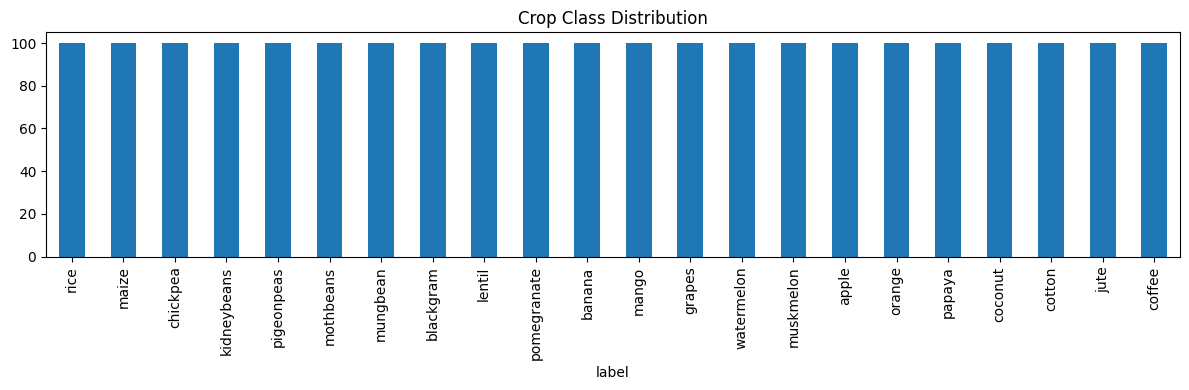


After SMOTE: 2200 samples (was 2200)
Class distribution after SMOTE:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [ ]:
if "label" in final_df.columns:
    print("\n► Crop label distribution (class balance check):")
    print(final_df["label"].value_counts())
    final_df["label"].value_counts().plot(kind="bar", figsize=(12, 4),
                                          title="Crop Class Distribution")
    plt.tight_layout(); plt.savefig("class_distribution.png", dpi=150)
    plt.show()

    # SMOTE oversampling — only on features, not lat/lon
    FEATURE_COLS = ["N","P","K","temperature","humidity","ph","rainfall",
                    "organic_carbon","soil_pH","sand"]
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(final_df["label"])

    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(final_df[FEATURE_COLS], y_encoded)
    print(f"\nAfter SMOTE: {X_res.shape[0]} samples (was {len(final_df)})")

    # Rebuild final_df with resampled data (no lat/lon — added back below)
    final_df_balanced = pd.DataFrame(X_res, columns=FEATURE_COLS)
    final_df_balanced["label"] = le.inverse_transform(y_res)
    # Assign median coordinates per crop type for SMOTE-generated rows
    coord_medians = final_df.groupby("label")[["longitude","latitude"]].median()
    final_df_balanced = final_df_balanced.merge(coord_medians,
                                                on="label", how="left")
    final_df = final_df_balanced.copy()
    print("Class distribution after SMOTE:")
    print(final_df["label"].value_counts())


In [ ]:
try:
    import ee
    ee.Authenticate()   # Opens browser OAuth flow in Colab
    ee.Initialize(project="sage-loop-472509-u2")   # ← replace with your project
    GEE_AVAILABLE = True
    print("✅ Google Earth Engine initialised.")
except Exception as exc:
    GEE_AVAILABLE = False
    print(f"⚠ GEE not available ({exc}). NDVI will be derived analytically.")

✅ Google Earth Engine initialised.


In [ ]:
START_DATE = "2020-01-01"
END_DATE   = "2021-12-31"

def extract_ndvi_for_point(lon, lat, start=START_DATE, end=END_DATE,
                            n_steps=TIMESTEPS):
    """
    Extract MODIS NDVI time-series for a single (lon, lat) location.

    Returns a list of n_steps NDVI values scaled to [0, 1].
    Missing acquisitions (cloud mask) are forward-filled.
    """
    point = ee.Geometry.Point([float(lon), float(lat)])

    collection = (
        ee.ImageCollection("MODIS/006/MOD13Q1")
        .filterDate(start, end)
        .filterBounds(point)
        .select("NDVI")
    )

    def get_value(image):
        date_str = image.date().format("YYYY-MM-dd")
        ndvi_val = image.reduceRegion(
            reducer  = ee.Reducer.mean(),
            geometry = point,
            scale    = 500
        ).get("NDVI")
        return ee.Feature(None, {"date": date_str, "NDVI": ndvi_val})

    features = collection.map(get_value).getInfo()["features"]
    values   = [f["properties"]["NDVI"] for f in features
                if f["properties"]["NDVI"] is not None]

    # MODIS NDVI scale factor: divide by 10000 to get [-1, 1]
    values = [v / 10000.0 for v in values]

    # Pad or truncate to exactly n_steps
    if len(values) == 0:
        values = [0.5] * n_steps         # neutral fill if no data
    elif len(values) < n_steps:
        values = values + [values[-1]] * (n_steps - len(values))
    else:
        values = values[:n_steps]

    return values


def batch_extract_ndvi(df, lon_col="longitude", lat_col="latitude",
                        sample_limit=None):
    """
    Extract NDVI sequences for all rows in df.

    sample_limit: if set, only process the first N unique locations
                  (useful for testing without quota exhaustion).
    """
    coords = df[[lon_col, lat_col]].drop_duplicates().reset_index(drop=True)
    if sample_limit:
        coords = coords.head(sample_limit)

    print(f"  Extracting NDVI for {len(coords)} unique locations …")
    cache = {}
    for i, row in coords.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        try:
            cache[key] = extract_ndvi_for_point(key[0], key[1])
            if i % 50 == 0:
                print(f"    {i}/{len(coords)} done …", flush=True)
        except Exception as e:
            print(f"    ⚠ GEE error at {key}: {e}")
            cache[key] = [0.5] * TIMESTEPS

    ndvi_sequences = []
    for _, row in df.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        ndvi_sequences.append(cache.get(key, [0.5] * TIMESTEPS))

    return ndvi_sequences


In [ ]:
def derive_ndvi_analytically(df, n_steps=TIMESTEPS):
    """
    Estimate a plausible NDVI time-series from crop/soil features.

    NDVI baseline is a weighted combination of:
      • organic_carbon  (higher OC → denser vegetation)
      • rainfall        (more rain → greener)
      • humidity        (supports transpiration)
      • temperature     (optimal ~25°C)
    Seasonal variation is added using a cosine wave.
    """
    print("  Using analytical NDVI derivation (no GEE connection).")

    # Normalise predictors to [0,1]
    scaler = MinMaxScaler()
    features = scaler.fit_transform(
        df[["organic_carbon", "rainfall", "humidity", "temperature"]]
    )
    oc_n, rain_n, hum_n, temp_n = features.T

    # Baseline NDVI (weights derived from literature)
    ndvi_base = 0.35 * oc_n + 0.30 * rain_n + 0.20 * hum_n + 0.15 * temp_n
    ndvi_base = np.clip(ndvi_base, 0.05, 0.90)

    # Seasonal cosine signal (annual cycle across n_steps)
    t = np.linspace(0, 2 * np.pi, n_steps)
    seasonal = 0.10 * np.cos(t - np.pi / 4)   # peak in growing season

    ndvi_sequences = []
    for base in ndvi_base:
        seq = np.clip(base + seasonal + np.random.normal(0, 0.02, n_steps),
                      0.0, 1.0)
        ndvi_sequences.append(seq.tolist())

    return ndvi_sequences


# Extract NDVI
if GEE_AVAILABLE:
    print("\n► Extracting NDVI via GEE (this may take several minutes) …")
    ndvi_seqs = batch_extract_ndvi(final_df, sample_limit=None)
else:
    ndvi_seqs = derive_ndvi_analytically(final_df)

# Add NDVI columns to dataframe
ndvi_cols = [f"ndvi_t{i+1}" for i in range(TIMESTEPS)]
ndvi_df   = pd.DataFrame(ndvi_seqs, columns=ndvi_cols)
final_df  = pd.concat([final_df.reset_index(drop=True), ndvi_df], axis=1)

print(f"\n✅ NDVI added. Dataset shape: {final_df.shape}")
print(final_df[ndvi_cols].describe().round(3).to_string())



► Extracting NDVI via GEE (this may take several minutes) …
  Extracting NDVI for 21 unique locations …


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for MODIS/006/MOD13Q1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by MODIS/061/MOD13Q1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MOD13Q1

  warnings.warn(warning, category=DeprecationWarning)


    0/21 done …

✅ NDVI added. Dataset shape: (2200, 21)
        ndvi_t1   ndvi_t2   ndvi_t3   ndvi_t4   ndvi_t5   ndvi_t6   ndvi_t7   ndvi_t8
count  2200.000  2200.000  2200.000  2200.000  2200.000  2200.000  2200.000  2200.000
mean      0.387     0.367     0.349     0.326     0.327     0.337     0.353     0.385
std       0.145     0.146     0.136     0.120     0.132     0.140     0.145     0.164
min       0.230     0.213     0.209     0.200     0.197     0.203     0.201     0.200
25%       0.296     0.274     0.274     0.249     0.239     0.241     0.242     0.262
50%       0.332     0.319     0.305     0.291     0.291     0.298     0.316     0.330
75%       0.413     0.387     0.350     0.329     0.352     0.397     0.455     0.500
max       0.762     0.790     0.759     0.681     0.806     0.829     0.845     0.867


In [ ]:
"""
Open-Meteo (https://open-meteo.com/) provides free ERA5-reanalysis weather data.
No API key required. Rate limit: ~10 000 calls/day.
"""
import urllib.request, json

def fetch_weather_history(lon, lat, n_steps=TIMESTEPS,
                           start="2020-01-01", end="2020-12-31"):
    """
    Fetch monthly-averaged temperature (°C) and precipitation (mm)
    for the past n_steps months from Open-Meteo ERA5 reanalysis.

    Returns temp_seq, rain_seq — each a list of n_steps values.
    """
    url = (
        f"https://archive-api.open-meteo.com/v1/era5"
        f"?latitude={lat:.4f}&longitude={lon:.4f}"
        f"&start_date={start}&end_date={end}"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&timezone=UTC"
    )
    try:
        with urllib.request.urlopen(url, timeout=10) as resp:
            data = json.load(resp)
        daily_temp = data["daily"]["temperature_2m_mean"]
        daily_rain = data["daily"]["precipitation_sum"]

        # Resample to n_steps by chunking daily data
        chunk = max(1, len(daily_temp) // n_steps)
        temp_seq = [np.nanmean(daily_temp[i:i+chunk])
                    for i in range(0, n_steps * chunk, chunk)][:n_steps]
        rain_seq = [np.nansum(daily_rain[i:i+chunk])
                    for i in range(0, n_steps * chunk, chunk)][:n_steps]

        # Pad if short
        while len(temp_seq) < n_steps: temp_seq.append(temp_seq[-1])
        while len(rain_seq) < n_steps: rain_seq.append(rain_seq[-1])
        return temp_seq[:n_steps], rain_seq[:n_steps]

    except Exception:
        # Fallback: replicate single values across timesteps
        return ([np.nan] * n_steps, [np.nan] * n_steps)


def batch_fetch_weather(df, lon_col="longitude", lat_col="latitude",
                         n_steps=TIMESTEPS, enable=True):
    """Fetch weather for all unique locations; fall back to row-level values."""
    if not enable:
        print("  Weather API disabled — replicating static values.")
        temp_seqs = [[row["temperature"]] * n_steps
                     for _, row in df.iterrows()]
        rain_seqs = [[row["rainfall"]]    * n_steps
                     for _, row in df.iterrows()]
        return temp_seqs, rain_seqs

    coords = df[[lon_col, lat_col]].drop_duplicates()
    cache  = {}
    print(f"  Fetching weather for {len(coords)} unique locations …")
    for i, (_, row) in enumerate(coords.iterrows()):
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        cache[key] = fetch_weather_history(key[0], key[1], n_steps)
        if i % 20 == 0:
            print(f"    {i}/{len(coords)} …", flush=True)

    temp_seqs, rain_seqs = [], []
    for _, row in df.iterrows():
        key = (round(row[lon_col], 4), round(row[lat_col], 4))
        t, r = cache.get(key, ([row["temperature"]] * n_steps,
                                [row["rainfall"]]    * n_steps))
        temp_seqs.append(t)
        rain_seqs.append(r)
    return temp_seqs, rain_seqs


# Toggle: set FETCH_WEATHER=True to call Open-Meteo
FETCH_WEATHER = False   # ← set True in Colab to enable real API calls

temp_seqs, rain_seqs = batch_fetch_weather(final_df, enable=FETCH_WEATHER)

# Add to dataframe
temp_cols = [f"temp_t{i+1}"  for i in range(TIMESTEPS)]
rain_cols = [f"rain_t{i+1}"  for i in range(TIMESTEPS)]

final_df = pd.concat([
    final_df,
    pd.DataFrame(temp_seqs, columns=temp_cols),
    pd.DataFrame(rain_seqs, columns=rain_cols)
], axis=1)

print(f"\n✅ Weather time-series added. Dataset shape: {final_df.shape}")

  Weather API disabled — replicating static values.

✅ Weather time-series added. Dataset shape: (2200, 37)



► Soil Health Index statistics:
count    2200.0000
mean        0.4089
std         0.0643
min         0.2155
25%         0.3626
50%         0.4041
75%         0.4512
max         0.6115
Name: soil_health_index, dtype: float64


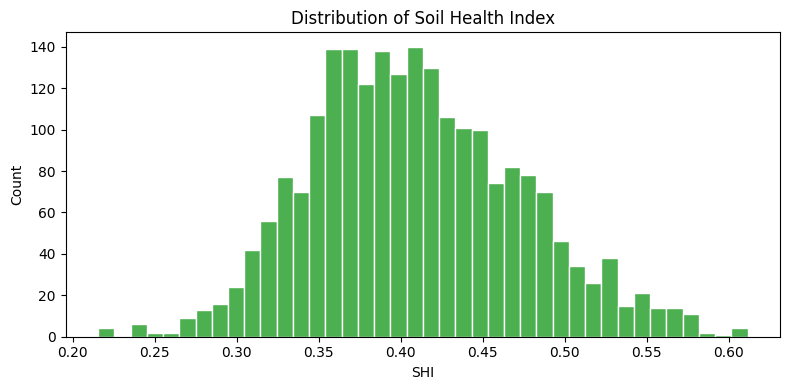

In [ ]:
"""
Soil Health Index (SHI) — composite score from 5 indicators:
  ① organic_carbon  — higher is better (carbon sequestration, nutrient cycling)
  ② mean NDVI       — higher is better (vegetation vigour)
  ③ soil_pH         — optimal near 6.5; penalise extremes
  ④ humidity        — moderate values optimal
  ⑤ rainfall        — adequate but not excessive

Each component is normalised to [0,1]; SHI = weighted sum.
"""
def compute_soil_health_index(df):
    scaler = MinMaxScaler()

    oc_n   = scaler.fit_transform(df[["organic_carbon"]]).flatten()
    ndvi_n = df[[f"ndvi_t{i+1}" for i in range(TIMESTEPS)]].mean(axis=1).values
    ndvi_n = MinMaxScaler().fit_transform(ndvi_n.reshape(-1,1)).flatten()

    # pH component: peak at 6.5, Gaussian-shaped penalty
    ph_raw = df["soil_pH"].values
    ph_n   = np.exp(-0.5 * ((ph_raw - 6.5) / 1.5) ** 2)   # Gaussian bell

    hum_n  = MinMaxScaler().fit_transform(df[["humidity"]]).flatten()
    # Humidity optimal ~60–80 %: bell around 70
    hum_n  = np.exp(-0.5 * ((df["humidity"].values - 70) / 20) ** 2)

    rain_n = MinMaxScaler().fit_transform(df[["rainfall"]]).flatten()

    # Weighted combination (weights sum to 1)
    SHI = (0.30 * oc_n +
           0.25 * ndvi_n +
           0.20 * ph_n +
           0.15 * hum_n +
           0.10 * rain_n)

    return np.clip(SHI, 0.0, 1.0)

final_df["soil_health_index"] = compute_soil_health_index(final_df)
print("\n► Soil Health Index statistics:")
print(final_df["soil_health_index"].describe().round(4))

plt.figure(figsize=(8, 4))
plt.hist(final_df["soil_health_index"], bins=40, color="#4CAF50", edgecolor="white")
plt.title("Distribution of Soil Health Index")
plt.xlabel("SHI"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("shi_distribution.png", dpi=150); plt.show()


In [ ]:
"""
For each sample, the time-series features at each timestep t are:
  [ndvi_t, temp_t, rain_t]   — shape (TIMESTEPS, 3)

Static soil/crop features are NOT part of the sequence but will be
concatenated in a hybrid model or used as initial hidden state.
"""
STATIC_FEATURES = ["N", "P", "K", "temperature", "humidity",
                    "ph", "rainfall", "organic_carbon", "soil_pH", "sand"]

seq_feature_names = ["ndvi", "temp", "rain"]

def build_sequences(df, timesteps=TIMESTEPS):
    """
    Returns
    -------
    X_seq    : np.array  (n, timesteps, 3)  — NDVI + temperature + rainfall
    X_static : np.array  (n, n_static)
    y        : np.array  (n,)               — soil_health_index
    """
    ndvi_arr = df[[f"ndvi_t{i+1}" for i in range(timesteps)]].values   # (n, T)
    temp_arr = df[[f"temp_t{i+1}" for i in range(timesteps)]].values
    rain_arr = df[[f"rain_t{i+1}" for i in range(timesteps)]].values

    # Stack → (n, T, 3)
    X_seq = np.stack([ndvi_arr, temp_arr, rain_arr], axis=-1)

    # Normalise per-feature across all samples and timesteps
    for f in range(X_seq.shape[-1]):
        mn, mx = X_seq[:,:,f].min(), X_seq[:,:,f].max()
        X_seq[:,:,f] = (X_seq[:,:,f] - mn) / (mx - mn + 1e-8)

    X_static = df[STATIC_FEATURES].values.astype(np.float32)
    X_static = MinMaxScaler().fit_transform(X_static)

    y = df["soil_health_index"].values.astype(np.float32)
    return X_seq.astype(np.float32), X_static, y

X_seq, X_static, y = build_sequences(final_df)
print(f"\n✅ Sequences built:")
print(f"   X_seq    : {X_seq.shape}   (samples, timesteps, features)")
print(f"   X_static : {X_static.shape}")
print(f"   y        : {y.shape}")



✅ Sequences built:
   X_seq    : (2200, 8, 3)   (samples, timesteps, features)
   X_static : (2200, 10)
   y        : (2200,)


In [ ]:
X_seq_tv, X_seq_test, X_st_tv, X_st_test, y_tv, y_test = train_test_split(
    X_seq, X_static, y, test_size=TEST_SPLIT, random_state=42)

val_frac = VAL_SPLIT / (1 - TEST_SPLIT)
X_seq_tr, X_seq_val, X_st_tr, X_st_val, y_tr, y_val = train_test_split(
    X_seq_tv, X_st_tv, y_tv, test_size=val_frac, random_state=42)

print(f"\n  Train      : {X_seq_tr.shape[0]} samples")
print(f"  Validation : {X_seq_val.shape[0]} samples")
print(f"  Test       : {X_seq_test.shape[0]} samples")


  Train      : 1540 samples
  Validation : 330 samples
  Test       : 330 samples


In [ ]:
def build_lstm_model(timesteps, seq_feats, static_feats):
    """
    Architecture:
      Sequence branch  → LSTM(128) → Dropout → LSTM(64)
      Static branch    → Dense(64) → ReLU
      Concat           → Dense(64) → Dense(32) → Dense(1)
    """
    seq_in   = layers.Input(shape=(timesteps, seq_feats), name="seq_input")
    static_in = layers.Input(shape=(static_feats,), name="static_input")

    # Sequence branch
    x = layers.LSTM(128, return_sequences=True, name="lstm_1")(seq_in)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64, return_sequences=False, name="lstm_2")(x)
    x = layers.Dropout(0.2)(x)

    # Static branch
    s = layers.Dense(64, activation="relu", name="static_dense")(static_in)
    s = layers.BatchNormalization()(s)

    # Merge
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(0.2)(merged)
    merged = layers.Dense(32, activation="relu")(merged)
    output = layers.Dense(1, activation="sigmoid", name="shi_output")(merged)

    model = Model(inputs=[seq_in, static_in], outputs=output, name="LSTM_SoilHealth")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse",
                  metrics=["mae"])
    return model

lstm_model = build_lstm_model(TIMESTEPS, X_seq.shape[-1], X_static.shape[-1])
lstm_model.summary()

Model: "LSTM_SoilHealth"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 8, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 8, 128)    │     67,584 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8, 128)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_dense        │ (None, 64)        │        704 │ static_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ static_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shi_output (Dense)  │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,321 (501.25 KB)

 Trainable params: 128,193 (500.75 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout_rate=0.1):
    """
    Standard Transformer encoder block:
      MultiHeadAttention → Add & Norm → FeedForward → Add & Norm
    """
    # Multi-Head Self-Attention
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads
    )(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    # Feed-Forward sub-layer
    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(d_model)(ff)
    ff = layers.Dropout(dropout_rate)(ff)
    x  = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x


def build_transformer_model(timesteps, seq_feats, static_feats,
                             d_model=D_MODEL, num_heads=N_HEADS,
                             ff_dim=128, n_blocks=2):
    """
    Architecture:
      Sequence branch  → Linear projection → Positional Encoding
                       → N × TransformerEncoderBlock → GlobalAvgPool
      Static branch    → Dense(64) → ReLU
      Concat           → Dense(64) → Dense(32) → Dense(1)
    """
    seq_in    = layers.Input(shape=(timesteps, seq_feats), name="seq_input")
    static_in = layers.Input(shape=(static_feats,), name="static_input")

    # Project to d_model
    x = layers.Dense(d_model, name="input_projection")(seq_in)

    # Learnable positional encoding (simpler than sinusoidal for regression)
    pos_enc = layers.Embedding(input_dim=timesteps, output_dim=d_model,
                               name="pos_encoding")
    positions = tf.range(start=0, limit=timesteps, delta=1)
    x = x + pos_enc(positions)

    # Stacked Transformer encoder blocks
    for i in range(n_blocks):
        x = transformer_encoder_block(x, d_model, num_heads, ff_dim)

    # Aggregate over time
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)

    # Static branch
    s = layers.Dense(64, activation="relu")(static_in)
    s = layers.BatchNormalization()(s)

    # Merge
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(0.2)(merged)
    merged = layers.Dense(32, activation="relu")(merged)
    output = layers.Dense(1, activation="sigmoid", name="shi_output")(merged)

    model = Model(inputs=[seq_in, static_in], outputs=output,
                  name="Transformer_SoilHealth")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse",
                  metrics=["mae"])
    return model

transformer_model = build_transformer_model(
    TIMESTEPS, X_seq.shape[-1], X_static.shape[-1])
transformer_model.summary()



Model: "Transformer_SoilHealth"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 8, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 8, 64)     │        256 │ seq_input[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 64)     │          0 │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 64)     │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 64)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 64)     │          0 │ add[0][0],        │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 64)     │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8, 64)     │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 64)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 64)     │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 64)     │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 8, 64)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 8, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 64)     │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8, 64)     │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 8, 64)     │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 8, 64)     │          0 │ layer_normalizat

 Total params: 78,529 (306.75 KB)

 Trainable params: 78,401 (306.25 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_{model_name}.h5", monitor="val_loss",
            save_best_only=True, verbose=0)
    ]


In [ ]:
print("\n" + "="*60)
print(" TRAINING LSTM MODEL")
print("="*60)

lstm_history = lstm_model.fit(
    [X_seq_tr, X_st_tr], y_tr,
    validation_data=([X_seq_val, X_st_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)


 TRAINING LSTM MODEL
Epoch 1/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0252 - mae: 0.1191

49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0115 - mae: 0.0754 - val_loss: 0.0075 - val_mae: 0.0726 - learning_rate: 0.0010
Epoch 2/60
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0030 - mae: 0.0431

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0026 - mae: 0.0400 - val_loss: 0.0062 - val_mae: 0.0648 - learning_rate: 0.0010
Epoch 3/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - mae: 0.0350

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0019 - mae: 0.0336 - val_loss: 0.0055 - val_mae: 0.0604 - learning_rate: 0.0010
Epoch 4/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0015 - mae: 0.0293

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0014 - mae: 0.0287 - val_loss: 0.0042 - val_mae: 0.0514 - learning_rate: 0.0010
Epoch 5/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - mae: 0.0283 - val_loss: 0.0049 - val_mae: 0.0573 - learning_rate: 0.0010
Epoch 6/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0012 - mae: 0.0268 - val_loss: 0.0043 - val_mae: 0.0537 - learning_rate: 0.0010
Epoch 7/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0011 - mae: 0.0254

...

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.6888e-04 - mae: 0.0150 - val_loss: 2.3023e-04 - val_mae: 0.0116 - learning_rate: 2.5000e-04
Epoch 35/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.2165e-04 - mae: 0.0141 - val_loss: 2.4966e-04 - val_mae: 0.0123 - learning_rate: 2.5000e-04
Epoch 36/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.6618e-04 - mae: 0.0147
Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.7376e-04 - mae: 0.0150 - val_loss: 2.3517e-04 - val_mae: 0.0117 - learning_rate: 2.5000e-04
Epoch 37/60
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.5679e-04 - mae: 0.0144

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.6490e-04 - mae: 0.0147 - val_loss: 2.2755e-04 - val_mae: 0.0111 - learning_rate: 1.2500e-04
Epoch 38/60
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.4191e-04 - mae: 0.0142

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.6317e-04 - mae: 0.0146 - val_loss: 2.2699e-04 - val_mae: 0.0111 - learning_rate: 1.2500e-04
Epoch 39/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.5152e-04 - mae: 0.0143

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.6237e-04 - mae: 0.0148 - val_loss: 2.2056e-04 - val_mae: 0.0108 - learning_rate: 1.2500e-04
Epoch 40/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.7979e-04 - mae: 0.0150 - val_loss: 2.2105e-04 - val_mae: 0.0109 - learning_rate: 1.2500e-04
Epoch 41/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.4795e-04 - mae: 0.0143
Epoch 41: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.5006e-04 - mae: 0.0143 - val_loss: 2.3203e-04 - val_mae: 0.0112 - learning_rate: 1.2500e-04
Epoch 42/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.3479e-04 - mae: 0.0142

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.5329e-04 - mae: 0.0146 - val_loss: 2.1524e-04 - val_mae: 0.0106 - learning_rate: 6.2500e-05
Epoch 43/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.3881e-04 - mae: 0.0142 - val_loss: 2.2094e-04 - val_mae: 0.0109 - learning_rate: 6.2500e-05
Epoch 44/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.4894e-04 - mae: 0.0143 - val_loss: 2.1890e-04 - val_mae: 0.0108 - learning_rate: 6.2500e-05
Epoch 45/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5034e-04 - mae: 0.0144 - val_loss: 2.2732e-04 - val_mae: 0.0110 - learning_rate: 6.2500e-05
Epoch 46/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.5275e-04 - mae: 0.0145
Epoch 46: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5999e-04 - mae: 0.0145 - val_loss: 2.3332e-04 - val_mae: 0.0113 - learning_rate: 6.2500e-05
Epoch 47/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.3947e-04 - mae: 0.0142 - val_l

In [ ]:
print("\n" + "="*60)
print(" TRAINING TRANSFORMER MODEL")
print("="*60)

trans_history = transformer_model.fit(
    [X_seq_tr, X_st_tr], y_tr,
    validation_data=([X_seq_val, X_st_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("transformer"),
    verbose=1
)


 TRAINING TRANSFORMER MODEL
Epoch 1/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0257 - mae: 0.1215

49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0124 - mae: 0.0818 - val_loss: 0.0058 - val_mae: 0.0627 - learning_rate: 0.0010
Epoch 2/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0031 - mae: 0.0432 - val_loss: 0.0059 - val_mae: 0.0633 - learning_rate: 0.0010
Epoch 3/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0024 - mae: 0.0393

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0022 - mae: 0.0372 - val_loss: 0.0049 - val_mae: 0.0569 - learning_rate: 0.0010
Epoch 4/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0020 - mae: 0.0347

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0019 - mae: 0.0341 - val_loss: 0.0046 - val_mae: 0.0547 - learning_rate: 0.0010
Epoch 5/60
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0016 - mae: 0.0314

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0016 - mae: 0.0313 - val_loss: 0.0043 - val_mae: 0.0520 - learning_rate: 0.0010
Epoch 6/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0015 - mae: 0.0301

...

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.4097e-04 - mae: 0.0164 - val_loss: 3.9543e-04 - val_mae: 0.0156 - learning_rate: 3.1250e-05
Epoch 47/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.0114e-04 - mae: 0.0172 - val_loss: 4.1307e-04 - val_mae: 0.0160 - learning_rate: 3.1250e-05
Epoch 48/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 4.5080e-04 - mae: 0.0165 - val_loss: 3.9924e-04 - val_mae: 0.0157 - learning_rate: 3.1250e-05
Epoch 49/60
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.3842e-04 - mae: 0.0162

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.8056e-04 - mae: 0.0171 - val_loss: 3.9131e-04 - val_mae: 0.0155 - learning_rate: 3.1250e-05
Epoch 50/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.7678e-04 - mae: 0.0171
Epoch 50: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.8355e-04 - mae: 0.0172 - val_loss: 3.9326e-04 - val_mae: 0.0155 - learning_rate: 3.1250e-05
Epoch 51/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.5751e-04 - mae: 0.0167

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.7650e-04 - mae: 0.0168 - val_loss: 3.8958e-04 - val_mae: 0.0154 - learning_rate: 1.5625e-05
Epoch 52/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.7993e-04 - mae: 0.0170 - val_loss: 3.9560e-04 - val_mae: 0.0156 - learning_rate: 1.5625e-05
Epoch 53/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.8558e-04 - mae: 0.0170 - val_loss: 3.9001e-04 - val_mae: 0.0154 - learning_rate: 1.5625e-05
Epoch 54/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.7964e-04 - mae: 0.0171 - val_loss: 3.8958e-04 - val_mae: 0.0155 - learning_rate: 1.5625e-05
Epoch 55/60
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.2313e-04 - mae: 0.0160
Epoch 55: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.8266e-04 - mae: 0.0169 - val_loss: 3.8342e-04 - val_mae: 0.0153 - learning_rate: 1.5625e-05
Epoch 56/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.6953e-04 - mae: 0.0168 - val_loss: 3.8691e-04 - val_mae: 0.0154 - learning_rate: 7.8125e-06
Epoch 57/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 5.0271e-04 - mae: 0.0175 - val_loss: 3.8711e-04 - val_mae: 0.0154 - learning_rate: 7.8125e-06
Epoch 58/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 4.5407e-04 - mae: 0.0164 - val_loss: 3.8956e-04 - val_mae: 0.0154 - learning_rate: 7.8125e-06
Epoch 59/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.7542e-04 - mae: 0.0167 - val_loss: 3.8471e-04 - val_mae: 0.0153 - learning_rate: 7.8125e-06
Epoch 60/60
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.4352e-04 - mae: 0.0163
Epoch 60: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.6584e-04 - mae: 0.0168 - val_loss: 3.8229e-04 - val_mae: 0.0153 - learning_rate: 7.8125e-06
Restoring model weights from the end of the best epoch: 60.


In [ ]:
def evaluate_model(model, X_seq_test, X_st_test, y_test, model_name):
    y_pred = model.predict([X_seq_test, X_st_test], verbose=0).flatten()
    mse    = np.mean((y_test - y_pred) ** 2)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mse)
    # R² score
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2     = 1 - ss_res / (ss_tot + 1e-8)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Set Metrics")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return y_pred, {"mae": mae, "rmse": rmse, "mse": mse, "r2": r2}

y_pred_lstm,  lstm_metrics  = evaluate_model(
    lstm_model, X_seq_test, X_st_test, y_test, "LSTM")
y_pred_trans, trans_metrics = evaluate_model(
    transformer_model, X_seq_test, X_st_test, y_test, "Transformer")




  LSTM — Test Set Metrics
  MAE  : 0.0103
  RMSE : 0.0135
  MSE  : 0.0002
  R²   : 0.9529

  Transformer — Test Set Metrics
  MAE  : 0.0147
  RMSE : 0.0184
  MSE  : 0.0003
  R²   : 0.9131


In [3]:
def plot_history(history, model_name, color):
    epochs_range = range(1, len(history.history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs_range, history.history["loss"],
                 label="Train Loss", color=color, linewidth=2)
    axes[0].plot(epochs_range, history.history["val_loss"],
                 label="Val Loss", color=color, linestyle="--", linewidth=2)
    axes[0].set_title("MSE Loss"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # MAE
    axes[1].plot(epochs_range, history.history["mae"],
                 label="Train MAE", color=color, linewidth=2)
    axes[1].plot(epochs_range, history.history["val_mae"],
                 label="Val MAE", color=color, linestyle="--", linewidth=2)
    axes[1].set_title("MAE"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"{model_name.lower()}_training_history.png"
    plt.savefig(fname, dpi=150); plt.show()
    print(f"  Saved ➜ {fname}")

plot_history(lstm_history,  "LSTM",        "#1976D2")
plot_history(trans_history, "Transformer", "#E53935")


NameError: name 'lstm_history' is not defined

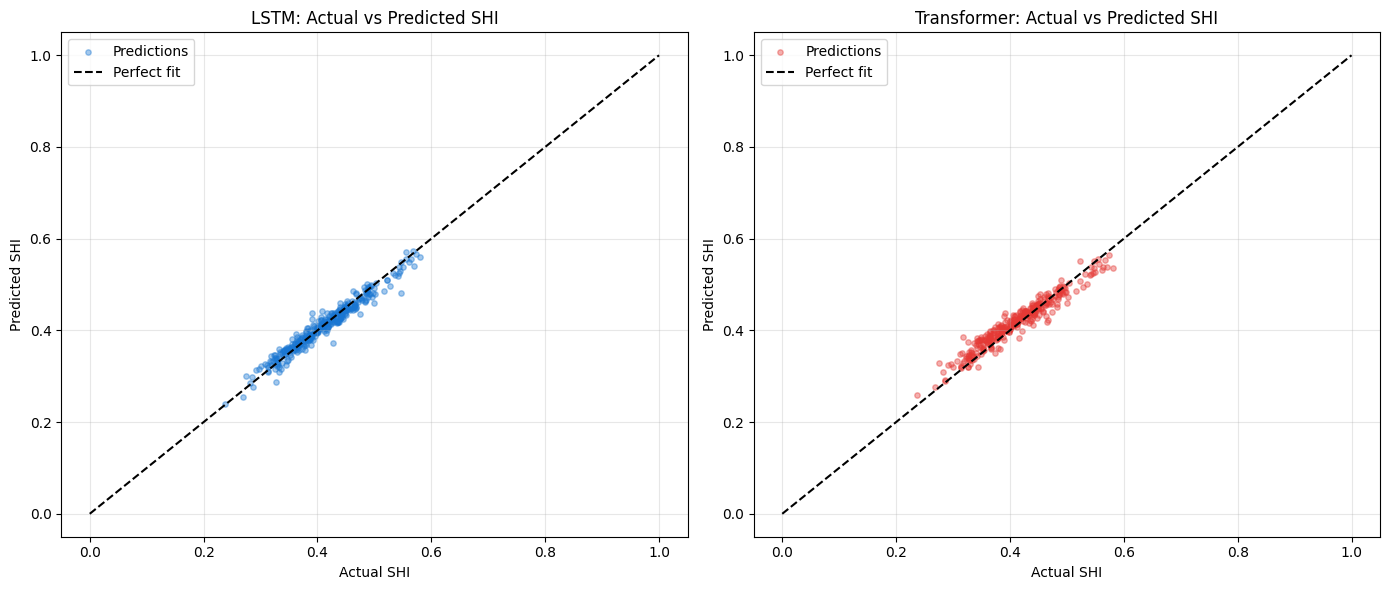

Saved ➜ predictions_scatter.png


In [ ]:
def plot_predictions(y_true, y_lstm, y_trans):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    perfect = np.linspace(0, 1, 50)

    for ax, y_p, name, color in zip(
        axes,
        [y_lstm, y_trans],
        ["LSTM", "Transformer"],
        ["#1976D2", "#E53935"]
    ):
        ax.scatter(y_true, y_p, alpha=0.4, s=15, color=color, label="Predictions")
        ax.plot(perfect, perfect, "k--", linewidth=1.5, label="Perfect fit")
        ax.set_title(f"{name}: Actual vs Predicted SHI")
        ax.set_xlabel("Actual SHI"); ax.set_ylabel("Predicted SHI")
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("predictions_scatter.png", dpi=150); plt.show()
    print("Saved ➜ predictions_scatter.png")

plot_predictions(y_test, y_pred_lstm, y_pred_trans)


  MODEL COMPARISON SUMMARY
      Model      MAE     RMSE      MSE       R²
       LSTM 0.010332 0.013519 0.000183 0.952936
Transformer 0.014713 0.018367 0.000337 0.913137


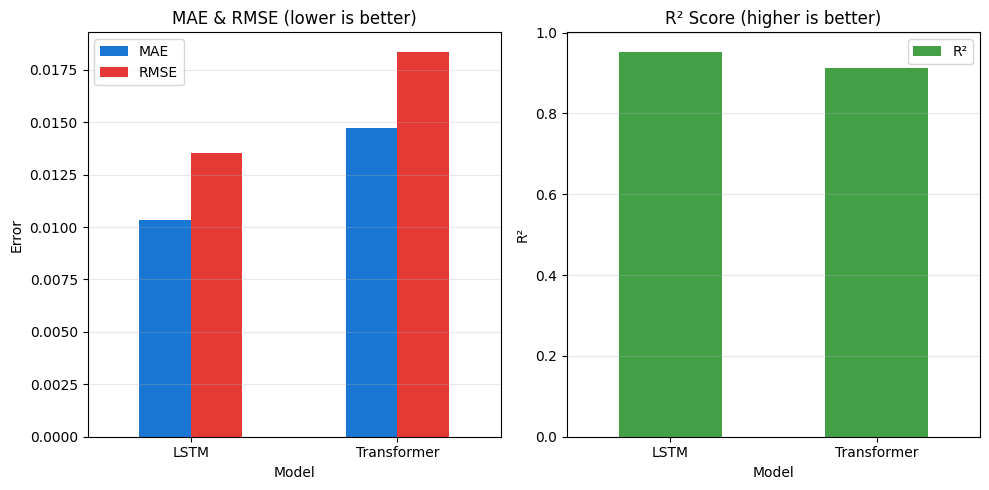

Saved ➜ model_comparison.png


In [ ]:
comparison = pd.DataFrame({
    "Model"     : ["LSTM", "Transformer"],
    "MAE"       : [lstm_metrics["mae"],  trans_metrics["mae"]],
    "RMSE"      : [lstm_metrics["rmse"], trans_metrics["rmse"]],
    "MSE"       : [lstm_metrics["mse"],  trans_metrics["mse"]],
    "R²"        : [lstm_metrics["r2"],   trans_metrics["r2"]],
})
print("\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)
print(comparison.to_string(index=False))
comparison.to_csv("model_comparison.csv", index=False)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
comparison.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar", ax=axes[0], color=["#1976D2","#E53935"], rot=0)
axes[0].set_title("MAE & RMSE (lower is better)")
axes[0].set_ylabel("Error"); axes[0].grid(axis="y", alpha=0.3)

comparison.set_index("Model")[["R²"]].plot(
    kind="bar", ax=axes[1], color=["#43A047","#FB8C00"], rot=0)
axes[1].set_title("R² Score (higher is better)")
axes[1].set_ylabel("R²"); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150); plt.show()
print("Saved ➜ model_comparison.png")

In [ ]:
lstm_model.save("lstm_soil_health.h5")
transformer_model.save("transformer_soil_health.h5")
final_df.to_csv("final_dataset_with_ndvi_weather.csv", index=False)

print("\n✅ All artefacts saved:")
print("  lstm_soil_health.h5")
print("  transformer_soil_health.h5")
print("  final_merged_dataset.csv")
print("  final_dataset_with_ndvi_weather.csv")
print("  model_comparison.csv")
print("  *.png  (training curves, scatter plots)")



✅ All artefacts saved:
  lstm_soil_health.h5
  transformer_soil_health.h5
  final_merged_dataset.csv
  final_dataset_with_ndvi_weather.csv
  model_comparison.csv
  *.png  (training curves, scatter plots)


In [ ]:
def predict_soil_health(model, sample_static, sample_ndvi,
                         sample_temp=None, sample_rain=None,
                         timesteps=TIMESTEPS):
    """
    Predict Soil Health Index for a new observation.

    Parameters
    ----------
    model         : trained Keras model
    sample_static : dict or array of 10 static features (in order of STATIC_FEATURES)
    sample_ndvi   : list of TIMESTEPS NDVI values
    sample_temp   : list of TIMESTEPS temperature values (optional)
    sample_rain   : list of TIMESTEPS rainfall values   (optional)
    """
    if sample_temp is None: sample_temp = [25.0] * timesteps
    if sample_rain is None: sample_rain = [100.0] * timesteps

    seq = np.array([sample_ndvi, sample_temp, sample_rain],
                   dtype=np.float32).T[np.newaxis, ...]   # (1, T, 3)

    if isinstance(sample_static, dict):
        sample_static = [sample_static[f] for f in STATIC_FEATURES]
    static = np.array(sample_static, dtype=np.float32)[np.newaxis, :]

    pred = model.predict([seq, static], verbose=0)[0, 0]
    print(f"  Predicted Soil Health Index: {pred:.4f}  "
          f"({'Healthy' if pred > 0.6 else 'Moderate' if pred > 0.4 else 'Poor'})")
    return pred


print("\n═" * 30)
print("PIPELINE COMPLETE.")
print("Use predict_soil_health() to score new observations.")
print("═" * 30)


═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
PIPELINE COMPLETE.
Use predict_soil_health() to score new observations.
══════════════════════════════


In [ ]:
"""
The SHI is a continuous regression target.  To compute classification metrics
we discretise predictions and ground-truth values into three health classes:

    Poor     → SHI  <  0.40
    Moderate → SHI  >= 0.40  and  < 0.65
    Healthy  → SHI  >= 0.65

Outputs:
  • Per-class Precision, Recall, F1-score
  • Overall Accuracy + Balanced Accuracy
  • Macro & Weighted averages
  • Confusion Matrix (raw counts + normalised %)
  • Per-class Accuracy bar chart
  • ROC-AUC (One-vs-Rest, multi-class)
  • Full summary table (CSV + PNG)
"""

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# ── 29-A  Discretise SHI into health classes ─────────────────────────────────
# Thresholds are computed from the TRAINING distribution (percentile-based)
# so all 3 classes are always populated — avoids the "Number of classes = 2"
# error that occurs when fixed thresholds leave a class empty in the test set.

def compute_adaptive_bins(shi_train, n_classes=3):
    """
    Return (n_classes-1) bin edges that split shi_train into equal-sized
    quantile groups, guaranteeing every class is represented.
    """
    quantiles = np.linspace(0, 100, n_classes + 1)[1:-1]  # e.g. [33.3, 66.6]
    edges     = np.percentile(shi_train, quantiles)
    return edges

# Derive bins from training labels only (no leakage from test)
_adaptive_edges = compute_adaptive_bins(y_tr)      # y_tr defined in Cell 17
print(f"\n► Adaptive SHI class thresholds (percentile-based):")
print(f"   Poor     : SHI  < {_adaptive_edges[0]:.3f}")
print(f"   Moderate : {_adaptive_edges[0]:.3f} ≤ SHI < {_adaptive_edges[1]:.3f}")
print(f"   Healthy  : SHI >= {_adaptive_edges[1]:.3f}")

CLASS_LABELS = ["Poor", "Moderate", "Healthy"]
ALL_CLASS_IDS = [0, 1, 2]

def shi_to_class(arr, edges=_adaptive_edges):
    """Map continuous SHI → integer class {0=Poor, 1=Moderate, 2=Healthy}."""
    return np.digitize(np.clip(arr, 0.0, 1.0), bins=edges)

y_test_cls       = shi_to_class(y_test)
y_pred_lstm_cls  = shi_to_class(y_pred_lstm)
y_pred_trans_cls = shi_to_class(y_pred_trans)

# Diagnostic: show which classes appear in each split
print("\n► Class distribution in test set:")
unique, counts = np.unique(y_test_cls, return_counts=True)
cls_map = dict(zip(unique, counts))
for i, label in enumerate(CLASS_LABELS):
    n = cls_map.get(i, 0)
    print(f"   {label:10s}: {n:4d} samples  ({100*n/len(y_test_cls):.1f}%)")

missing = [CLASS_LABELS[i] for i in ALL_CLASS_IDS if i not in cls_map]
if missing:
    print(f"   ⚠ Classes absent from test set: {missing}")
    print("     Using zero_division=0 in classification_report.")


► Adaptive SHI class thresholds (percentile-based):
   Poor     : SHI  < 0.375
   Moderate : 0.375 ≤ SHI < 0.432
   Healthy  : SHI >= 0.432

► Class distribution in test set:
   Poor      :   99 samples  (30.0%)
   Moderate  :  111 samples  (33.6%)
   Healthy   :  120 samples  (36.4%)


In [ ]:

# ── 29-B  Classification report ──────────────────────────────────────────────
def print_classification_report(y_true_cls, y_pred_cls, model_name):
    print(f"\n{'='*62}")
    print(f"  {model_name} — Classification Report")
    print(f"{'='*62}")
    acc  = accuracy_score(y_true_cls, y_pred_cls)
    bacc = balanced_accuracy_score(y_true_cls, y_pred_cls)
    print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Balanced Accuracy : {bacc:.4f}  ({bacc*100:.2f}%)")
    print()
    # Pass labels and target_names explicitly so all 3 classes always appear.
    # zero_division=0 silences warnings for classes absent from predictions.
    print(classification_report(
        y_true_cls, y_pred_cls,
        labels=ALL_CLASS_IDS,
        target_names=CLASS_LABELS,
        digits=4,
        zero_division=0
    ))
    return acc, bacc

lstm_acc,  lstm_bacc  = print_classification_report(
    y_test_cls, y_pred_lstm_cls,  "LSTM")
trans_acc, trans_bacc = print_classification_report(
    y_test_cls, y_pred_trans_cls, "Transformer")


  LSTM — Classification Report
  Accuracy          : 0.8727  (87.27%)
  Balanced Accuracy : 0.8732  (87.32%)

              precision    recall  f1-score   support

        Poor     0.9362    0.8889    0.9119        99
    Moderate     0.7851    0.8559    0.8190       111
     Healthy     0.9130    0.8750    0.8936       120

    accuracy                         0.8727       330
   macro avg     0.8781    0.8732    0.8748       330
weighted avg     0.8770    0.8727    0.8740       330


  Transformer — Classification Report
  Accuracy          : 0.7879  (78.79%)
  Balanced Accuracy : 0.7786  (77.86%)

              precision    recall  f1-score   support

        Poor     0.9688    0.6263    0.7607        99
    Moderate     0.6519    0.7928    0.7154       111
     Healthy     0.8397    0.9167    0.8765       120

    accuracy                         0.7879       330
   macro avg     0.8201    0.7786    0.7842       330
weighted avg     0.8152    0.7879    0.7876       330



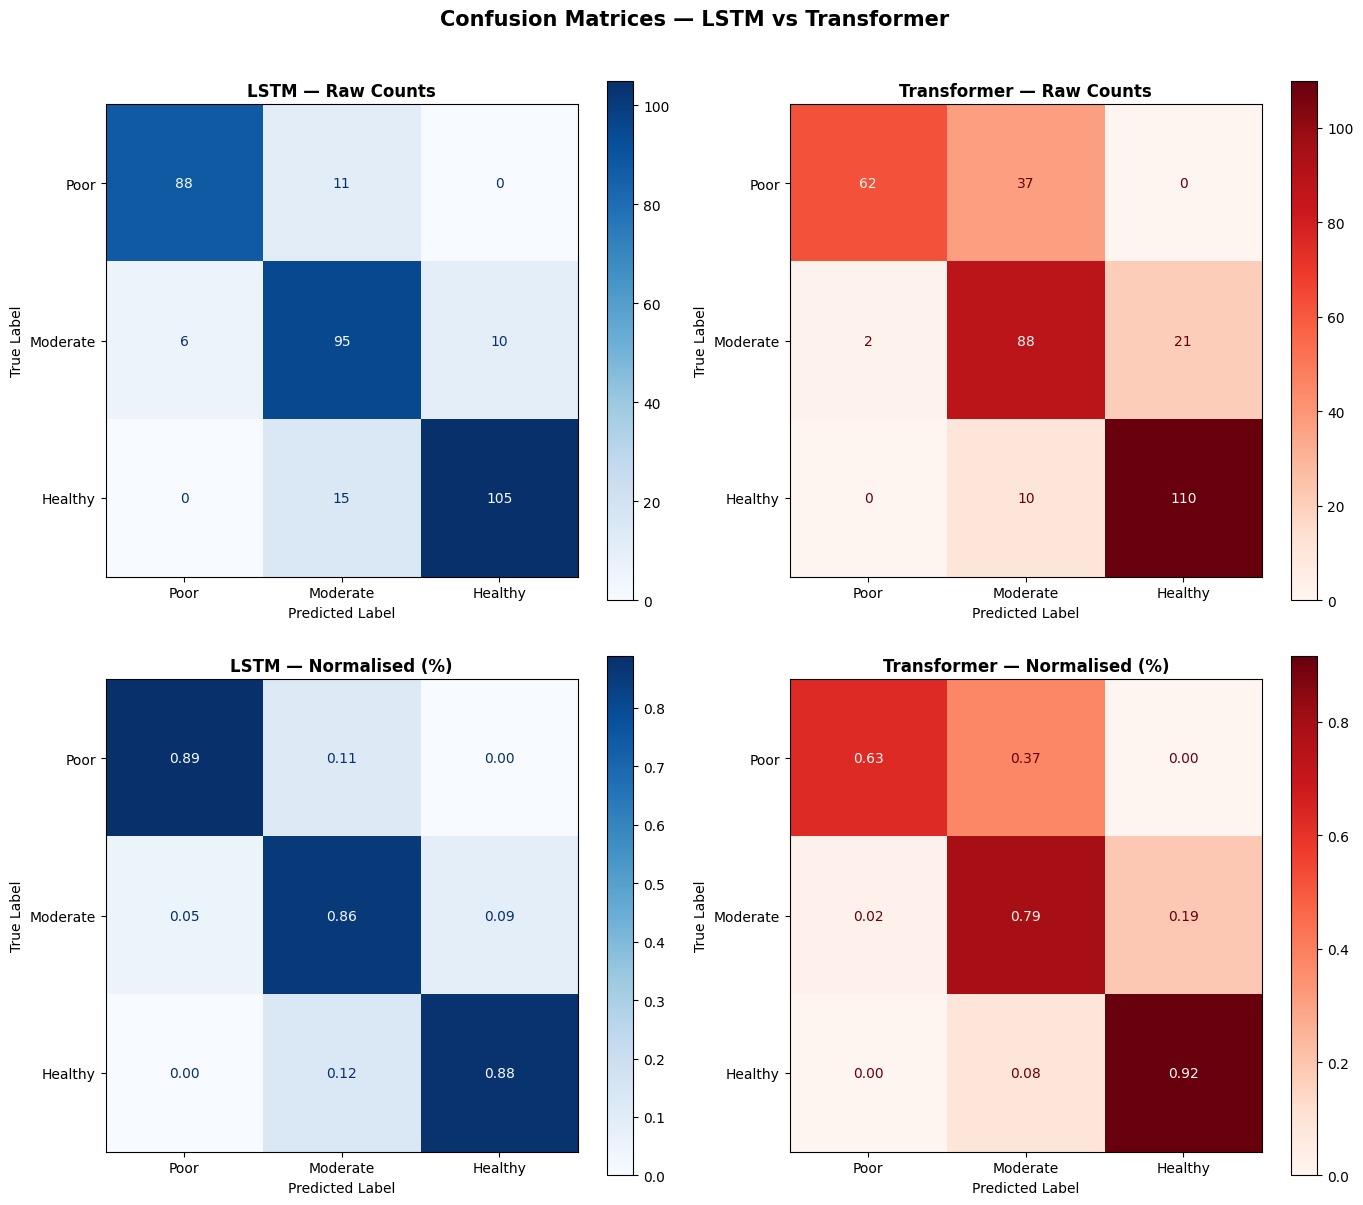

Saved ➜ confusion_matrices.png


In [ ]:
def plot_confusion_matrices(y_true, y_lstm, y_trans, labels):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle("Confusion Matrices — LSTM vs Transformer",
                 fontsize=15, fontweight="bold", y=1.01)

    configs = [
        (axes[0, 0], y_lstm,  "LSTM — Raw Counts",             False, "Blues"),
        (axes[0, 1], y_trans, "Transformer — Raw Counts",      False, "Reds"),
        (axes[1, 0], y_lstm,  "LSTM — Normalised (%)",         True,  "Blues"),
        (axes[1, 1], y_trans, "Transformer — Normalised (%)",  True,  "Reds"),
    ]

    for ax, y_pred, title, normalise, cmap in configs:
        norm = "true" if normalise else None
        cm   = confusion_matrix(y_true, y_pred, normalize=norm)
        fmt  = ".2f" if normalise else "d"
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=labels)
        disp.plot(ax=ax, colorbar=True, cmap=cmap, values_format=fmt)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Predicted Label", fontsize=10)
        ax.set_ylabel("True Label", fontsize=10)

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ➜ confusion_matrices.png")

plot_confusion_matrices(y_test_cls, y_pred_lstm_cls, y_pred_trans_cls,
                        CLASS_LABELS)

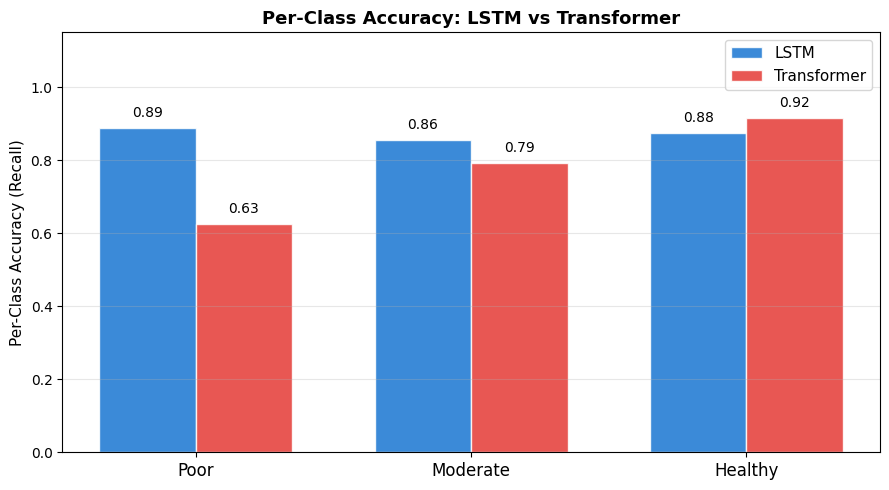

Saved ➜ per_class_accuracy.png


In [ ]:
def per_class_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm.diagonal() / cm.sum(axis=1)

lstm_pca  = per_class_accuracy(y_test_cls, y_pred_lstm_cls)
trans_pca = per_class_accuracy(y_test_cls, y_pred_trans_cls)

x     = np.arange(len(CLASS_LABELS))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lstm_pca,  width, label="LSTM",
               color="#1976D2", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, trans_pca, width, label="Transformer",
               color="#E53935", alpha=0.85, edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(CLASS_LABELS, fontsize=12)
ax.set_ylabel("Per-Class Accuracy (Recall)", fontsize=11)
ax.set_title("Per-Class Accuracy: LSTM vs Transformer",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15); ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150)
plt.show()
print("Saved ➜ per_class_accuracy.png")


  LSTM ROC-AUC per class:
    Poor      : 0.9888
    Moderate  : 0.4564
    Healthy   : 0.9857
    Macro     : 0.8103

  Transformer ROC-AUC per class:
    Poor      : 0.9853
    Moderate  : 0.4619
    Healthy   : 0.9771
    Macro     : 0.8081


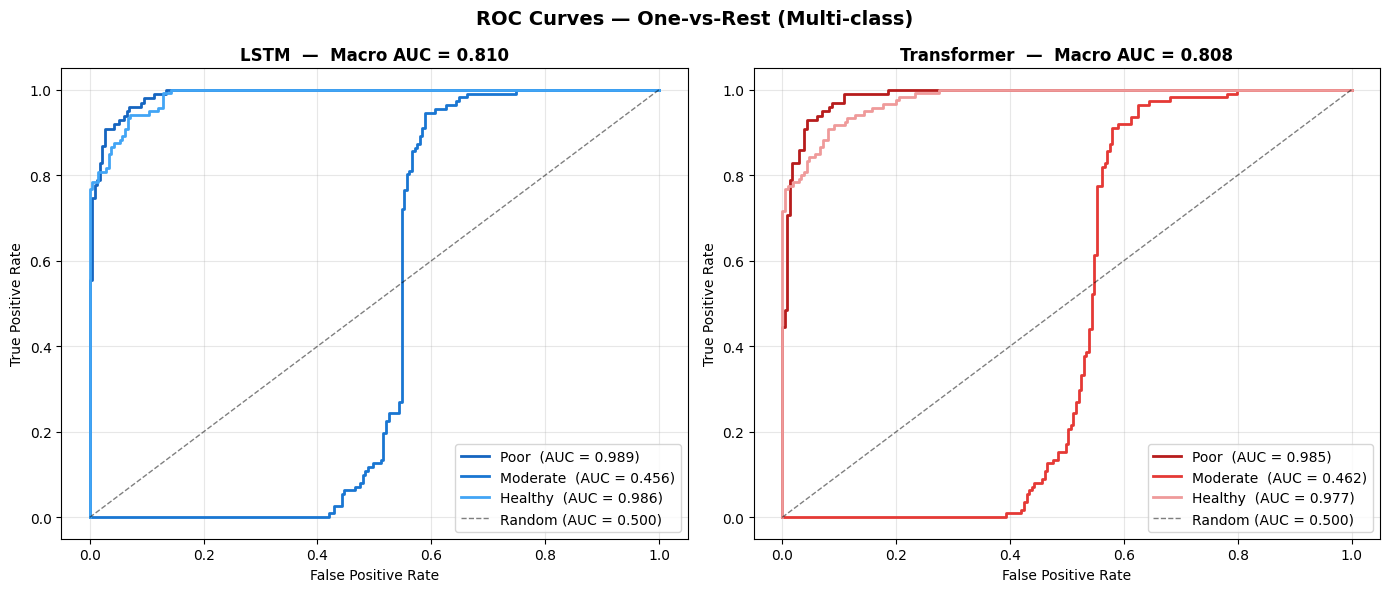

Saved ➜ roc_curves.png


In [ ]:
# ── 29-E  ROC-AUC curves (One-vs-Rest) ───────────────────────────────────────
def shi_to_proba(shi_arr):
    """
    Convert scalar SHI → (n, 3) soft probability matrix.
    Uses ordinal mapping centred on each class midpoint.
    """
    p_poor     = 1.0 - shi_arr
    p_healthy  = shi_arr
    p_moderate = 1.0 - np.abs(shi_arr - 0.525) / 0.525
    proba      = np.stack([p_poor, p_moderate, p_healthy], axis=1)
    proba      = np.clip(proba, 1e-6, None)
    proba      = proba / proba.sum(axis=1, keepdims=True)
    return proba

y_test_bin   = label_binarize(y_test_cls, classes=[0, 1, 2])
lstm_proba   = shi_to_proba(y_pred_lstm)
trans_proba  = shi_to_proba(y_pred_trans)

def plot_roc_curves(y_bin, proba_lstm, proba_trans, labels):
    colors_lstm  = ["#1565C0", "#1976D2", "#42A5F5"]
    colors_trans = ["#B71C1C", "#E53935", "#EF9A9A"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("ROC Curves — One-vs-Rest (Multi-class)",
                 fontsize=14, fontweight="bold")

    for ax, proba, model_name, colors in zip(
        axes,
        [proba_lstm, proba_trans],
        ["LSTM", "Transformer"],
        [colors_lstm, colors_trans]
    ):
        auc_scores = []
        for i, (label, color) in enumerate(zip(labels, colors)):
            fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
            roc_auc     = auc(fpr, tpr)
            auc_scores.append(roc_auc)
            ax.plot(fpr, tpr, color=color, linewidth=2,
                    label=f"{label}  (AUC = {roc_auc:.3f})")

        macro_auc = roc_auc_score(y_bin, proba,
                                   multi_class="ovr", average="macro")
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5,
                label="Random (AUC = 0.500)")
        ax.set_title(f"{model_name}  —  Macro AUC = {macro_auc:.3f}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

        print(f"\n  {model_name} ROC-AUC per class:")
        for label, score in zip(labels, auc_scores):
            print(f"    {label:10s}: {score:.4f}")
        print(f"    {'Macro':10s}: {macro_auc:.4f}")

    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150)
    plt.show()
    print("Saved ➜ roc_curves.png")

plot_roc_curves(y_test_bin, lstm_proba, trans_proba, CLASS_LABELS)

In [ ]:
# ── 29-F  Full classification summary table ───────────────────────────────────
lstm_auc  = roc_auc_score(y_test_bin, lstm_proba,
                           multi_class="ovr", average="macro")
trans_auc = roc_auc_score(y_test_bin, trans_proba,
                           multi_class="ovr", average="macro")

summary_cls = pd.DataFrame({
    "Model"            : ["LSTM", "Transformer"],
    "Accuracy (%)"     : [round(lstm_acc  * 100, 2), round(trans_acc  * 100, 2)],
    "Balanced Acc (%)": [round(lstm_bacc  * 100, 2), round(trans_bacc * 100, 2)],
    "Macro ROC-AUC"   : [round(lstm_auc,  4),        round(trans_auc,  4)],
    "Poor Acc (%)"    : [round(lstm_pca[0]  * 100, 2), round(trans_pca[0] * 100, 2)],
    "Moderate Acc (%)": [round(lstm_pca[1]  * 100, 2), round(trans_pca[1] * 100, 2)],
    "Healthy Acc (%)" : [round(lstm_pca[2]  * 100, 2), round(trans_pca[2] * 100, 2)],
})

print(f"\n{'='*70}")
print("  CELL 29 — COMPLETE CLASSIFICATION SUMMARY")
print(f"{'='*70}")
print(summary_cls.to_string(index=False))
summary_cls.to_csv("classification_summary.csv", index=False)
print("\nSaved ➜ classification_summary.csv")



  CELL 29 — COMPLETE CLASSIFICATION SUMMARY
      Model  Accuracy (%)  Balanced Acc (%)  Macro ROC-AUC  Poor Acc (%)  Moderate Acc (%)  Healthy Acc (%)
       LSTM         87.27             87.32         0.8103         88.89             85.59            87.50
Transformer         78.79             77.86         0.8081         62.63             79.28            91.67

Saved ➜ classification_summary.csv


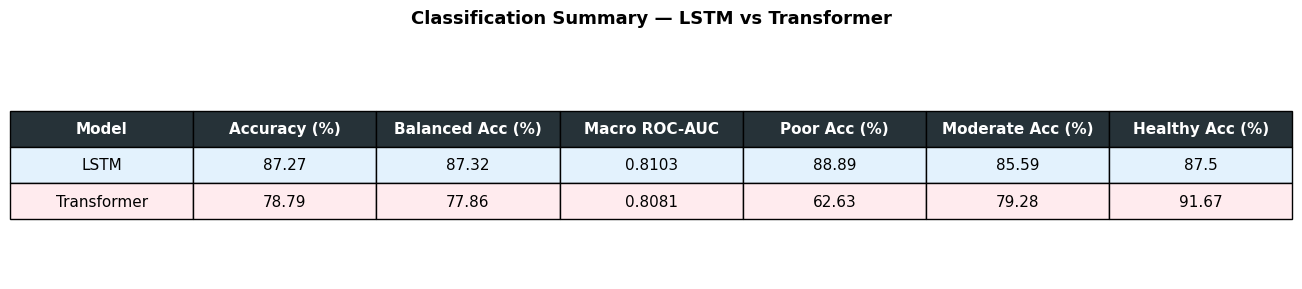

Saved ➜ classification_summary_table.png

✅ Cell 29 complete — classification metrics, confusion matrices,
   per-class accuracy, ROC curves and summary table all saved.


In [ ]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")
tbl = ax.table(cellText=summary_cls.values.tolist(),
               colLabels=summary_cls.columns.tolist(),
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.scale(1.2, 2.2)

# Header row styling
for j in range(len(summary_cls.columns)):
    tbl[0, j].set_facecolor("#263238")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Alternating row colours
row_colors = ["#E3F2FD", "#FFEBEE"]
for i in range(1, len(summary_cls) + 1):
    for j in range(len(summary_cls.columns)):
        tbl[i, j].set_facecolor(row_colors[(i - 1) % 2])

ax.set_title("Classification Summary — LSTM vs Transformer",
             fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("classification_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ➜ classification_summary_table.png")

print("\n✅ Cell 29 complete — classification metrics, confusion matrices,")
print("   per-class accuracy, ROC curves and summary table all saved.")

# **models comparison**


► Model parameter counts:
   LSTM                : 128,321
   Transformer         : 78,529
   GRU                 : 99,649
   BiLSTM              : 87,361
   CNN-LSTM            : 42,977
   TCN                 : 98,689
   CNN-Transformer     : 57,793
   Attention-LSTM      : 132,546

  TRAINING 6 NEW MODELS

▶ Training GRU …



Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 37: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


...

Restoring model weights from the end of the best epoch: 59.
   Done in 53s  |  best val_loss = 0.00030  |  epochs run = 60

▶ Training Attention-LSTM …



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 40: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 45: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 50: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 54: early stopping
Restoring model weights from the end of the best epoch: 44.
   Done in 72s  |  best val_loss = 0.00022  |  epochs run = 54

► Evaluating all 8 models on test set …
   LSTM                 | MAE=0.0103  R²=0.9529  Acc=87.3%  AUC=0.8103
   Transformer          | MAE=0.0147  R²=0.9131  Acc=78.8%  AUC=0.8081
   GRU                  | MAE=0.0096  R²=0.9595  Acc=90.3%  AUC=0.8115
   BiLSTM               | MAE=0.0111  R²=0.9486  Acc=86.7%  AUC=0.8075
   CNN-LSTM             | MAE=0.0111  R²=0.9498  Acc=87.3%  AUC=0.8103
   TCN                  | MAE=0.0094  R²=0.9619  Acc=91.5%  AUC=0.8137
   CNN-Transformer      | MAE=0.0132  R²=0.9310  Acc=86.1%  AUC=0.8073
   Attention-LSTM       | MAE=0.0100  R²=0.9554  Acc=86.4%  AUC=0.8080

  FULL 8-MODEL COMPARISON TABLE
 Rank           Model    MAE   RMSE     MSE     R²  A

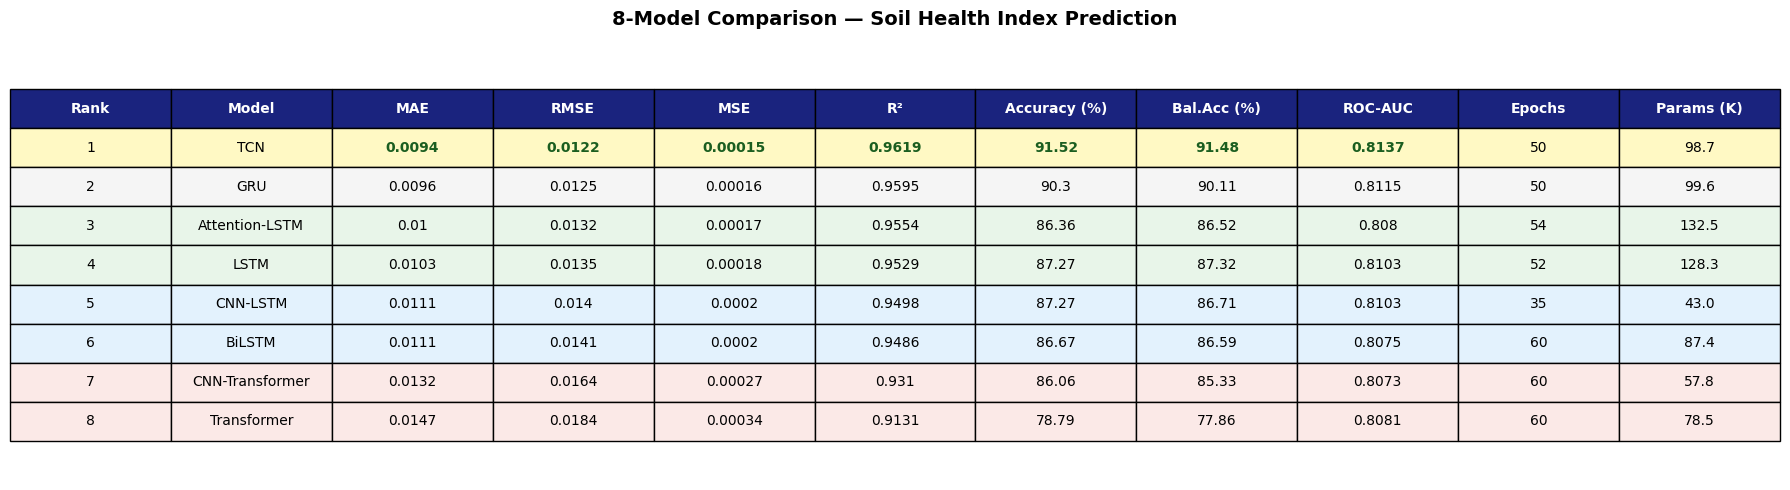

Saved ➜ 8model_comparison_table.png


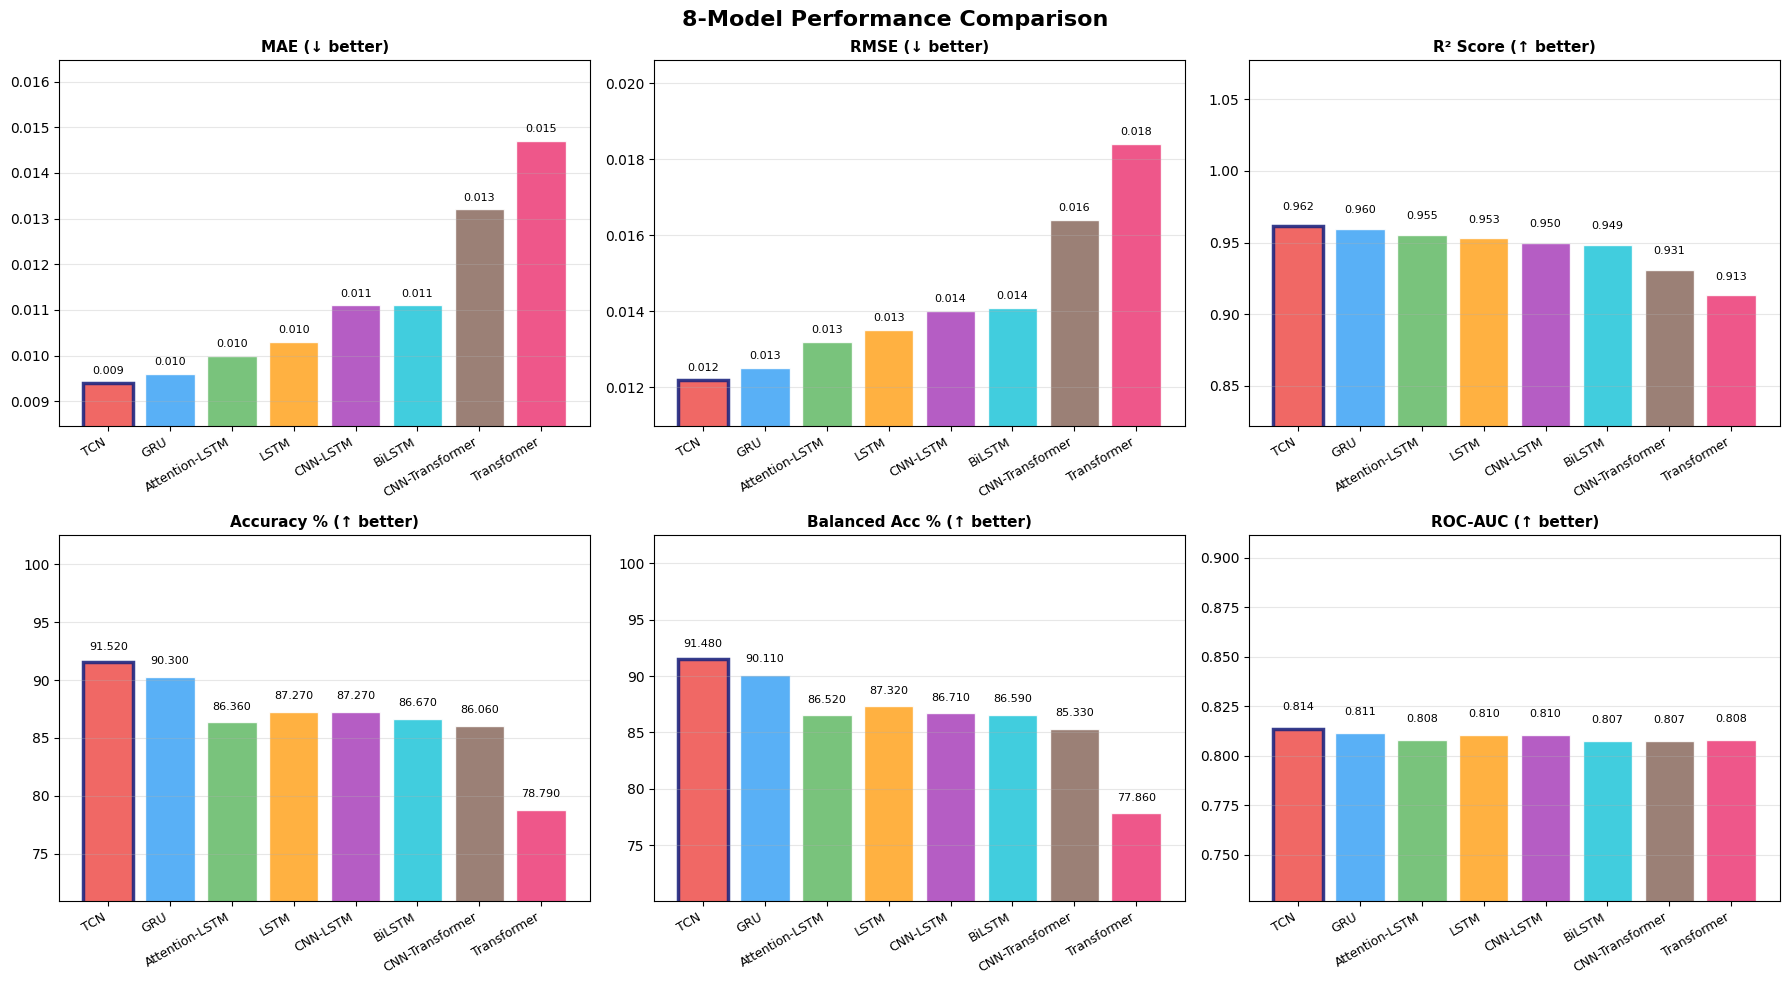

Saved ➜ 8model_bar_comparison.png


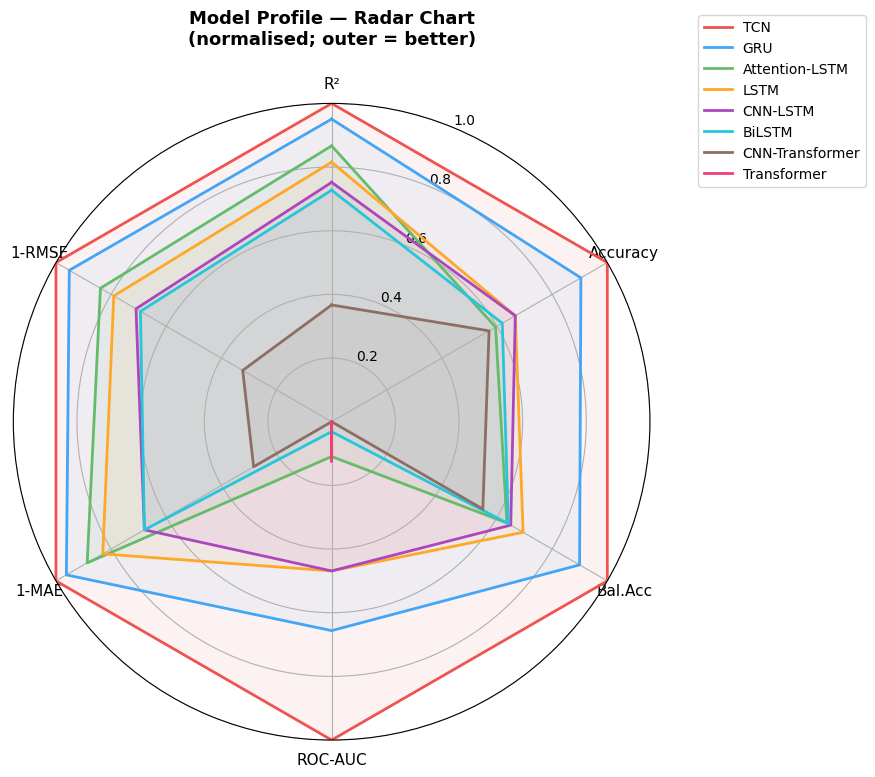

Saved ➜ 8model_radar_chart.png


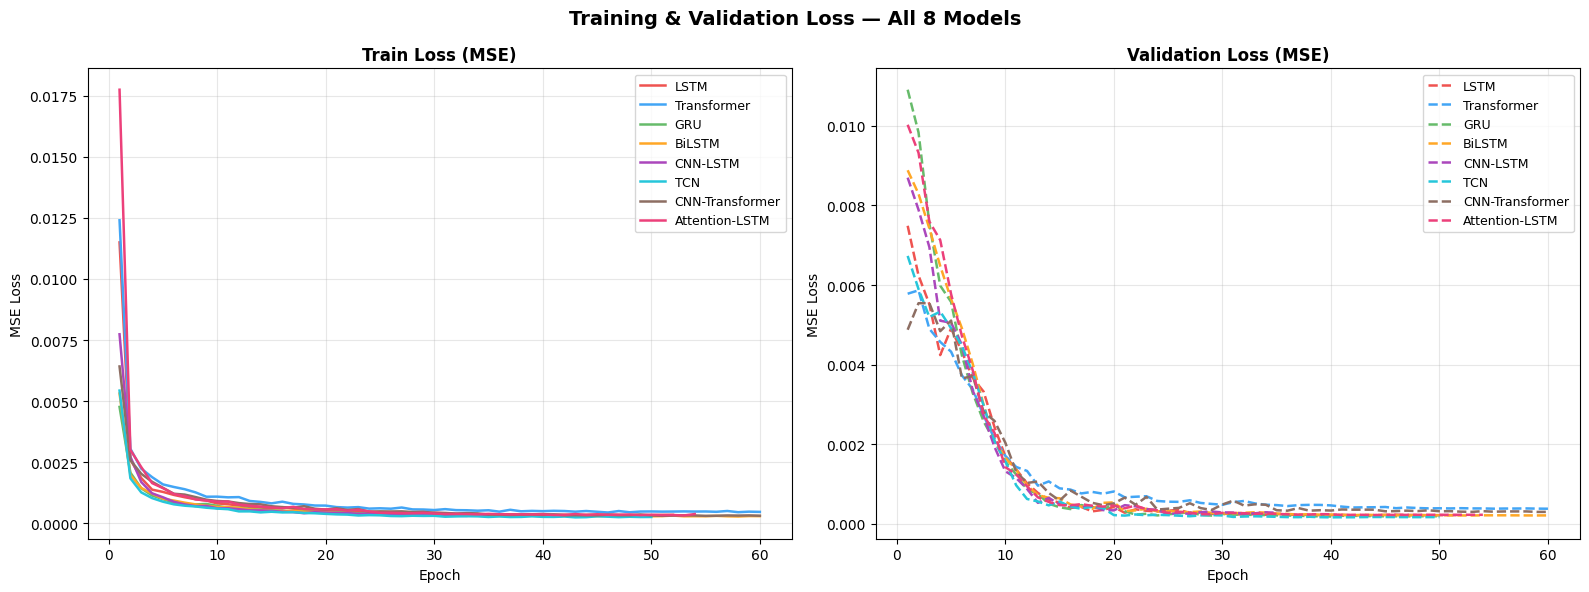

Saved ➜ 8model_loss_curves.png

  🏆 BEST MODEL: TCN
     R²           = 0.9619
     Accuracy     = 91.52%
     ROC-AUC      = 0.8137
     MAE          = 0.0094
     Parameters   = 98.7K

✅ Cell 30 complete — 8-model comparison table + 4 visualisations saved.


In [ ]:
#  CELL 30 ▸ 8-MODEL COMPARISON
#  Models: LSTM · Transformer · GRU · BiLSTM · CNN-LSTM ·
#          TCN  · CNN-Transformer · Attention-LSTM
# =============================================================================
"""
All 8 models share the same hybrid architecture pattern:
    Sequence branch  →  (model-specific layers)
    Static branch    →  Dense(64) + BN
    Concat           →  Dense(64) → Dense(32) → Dense(1, sigmoid)

This keeps the comparison fair — only the sequence encoder changes.
"""

import time
import math

# ── Helper: shared output head ────────────────────────────────────────────────
def _output_head(seq_out, static_in, name):
    """Attach static branch + regression head to any sequence encoder output."""
    s = layers.Dense(64, activation="relu")(static_in)
    s = layers.BatchNormalization()(s)
    x = layers.Concatenate()([seq_out, s])
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid", name="shi_output")(x)
    return out

def _compile(model):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse", metrics=["mae"])
    return model

T   = TIMESTEPS
SF  = X_seq.shape[-1]      # sequence features (3)
STF = X_static.shape[-1]   # static features (10)

# ─────────────────────────────────────────────────────────────────────────────
# MODEL C — GRU  (Gated Recurrent Unit, lighter than LSTM)
# ─────────────────────────────────────────────────────────────────────────────
def build_gru_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = layers.GRU(128, return_sequences=True)(seq_in)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(64,  return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    out = _output_head(x, static_in, "GRU")
    return _compile(Model([seq_in, static_in], out, name="GRU_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL D — Bidirectional LSTM  (captures past + future context)
# ─────────────────────────────────────────────────────────────────────────────
def build_bilstm_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(seq_in)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dropout(0.2)(x)
    out = _output_head(x, static_in, "BiLSTM")
    return _compile(Model([seq_in, static_in], out, name="BiLSTM_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL E — CNN-LSTM  (Conv1D extracts local patterns, LSTM models sequence)
# ─────────────────────────────────────────────────────────────────────────────
def build_cnn_lstm_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(seq_in)
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(pool_size=2, padding="same")(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    out = _output_head(x, static_in, "CNN_LSTM")
    return _compile(Model([seq_in, static_in], out, name="CNN_LSTM_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL F — Temporal Convolutional Network (TCN)
#   Stacked dilated causal convolutions — receptive field grows exponentially.
# ─────────────────────────────────────────────────────────────────────────────
def _tcn_residual_block(x, filters, kernel_size, dilation, dropout=0.2):
    """Single TCN residual block with dilated causal convolution."""
    # Causal padding = add (kernel_size-1)*dilation zeros on the LEFT only
    pad = (kernel_size - 1) * dilation
    # Conv path
    conv = layers.ZeroPadding1D((pad, 0))(x)
    conv = layers.Conv1D(filters, kernel_size, dilation_rate=dilation,
                         activation="relu", padding="valid")(conv)
    conv = layers.Dropout(dropout)(conv)
    conv = layers.ZeroPadding1D((pad, 0))(conv)
    conv = layers.Conv1D(filters, kernel_size, dilation_rate=dilation,
                         activation="relu", padding="valid")(conv)
    conv = layers.Dropout(dropout)(conv)
    # 1×1 residual projection if channels differ
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1)(x)
    return layers.Activation("relu")(layers.Add()([x, conv]))

def build_tcn_model(T, SF, STF, filters=64, kernel_size=3, n_blocks=4):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x = seq_in
    for i in range(n_blocks):
        x = _tcn_residual_block(x, filters, kernel_size, dilation=2**i)
    x = layers.GlobalAveragePooling1D()(x)
    out = _output_head(x, static_in, "TCN")
    return _compile(Model([seq_in, static_in], out, name="TCN_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL G — CNN + Transformer  (local features → global attention)
# ─────────────────────────────────────────────────────────────────────────────
def build_cnn_transformer_model(T, SF, STF, d_model=64, num_heads=4):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    # Local feature extraction
    x = layers.Conv1D(d_model, kernel_size=3, padding="same",
                      activation="relu")(seq_in)
    x = layers.Conv1D(d_model, kernel_size=3, padding="same",
                      activation="relu")(x)
    # Transformer encoder block
    attn = layers.MultiHeadAttention(num_heads=num_heads,
                                     key_dim=d_model // num_heads)(x, x)
    attn = layers.Dropout(0.1)(attn)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff   = layers.Dense(d_model * 2, activation="relu")(x)
    ff   = layers.Dense(d_model)(ff)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    x    = layers.GlobalAveragePooling1D()(x)
    x    = layers.Dropout(0.2)(x)
    out  = _output_head(x, static_in, "CNN_Trans")
    return _compile(Model([seq_in, static_in], out,
                          name="CNN_Transformer_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# MODEL H — Attention-LSTM  (Bahdanau-style self-attention over LSTM states)
# ─────────────────────────────────────────────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """Additive (Bahdanau) attention — computes soft weights over LSTM steps."""
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, hidden_states):
        # hidden_states: (batch, T, units)
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))   # (batch, T, 1)
        weights = tf.nn.softmax(score, axis=1)                 # (batch, T, 1)
        context = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, units)
        return context

def build_attention_lstm_model(T, SF, STF):
    seq_in    = layers.Input(shape=(T, SF),  name="seq_input")
    static_in = layers.Input(shape=(STF,),   name="static_input")
    x   = layers.LSTM(128, return_sequences=True)(seq_in)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(64,  return_sequences=True)(x)
    ctx = BahdanauAttention(64)(x)   # attended context vector
    ctx = layers.Dropout(0.2)(ctx)
    out = _output_head(ctx, static_in, "Attn_LSTM")
    return _compile(Model([seq_in, static_in], out,
                          name="AttentionLSTM_SoilHealth"))

# ─────────────────────────────────────────────────────────────────────────────
# Instantiate all 8 models
# ─────────────────────────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    "LSTM"            : lstm_model,           # already trained in Cell 21
    "Transformer"     : transformer_model,    # already trained in Cell 22
    "GRU"             : build_gru_model(T, SF, STF),
    "BiLSTM"          : build_bilstm_model(T, SF, STF),
    "CNN-LSTM"        : build_cnn_lstm_model(T, SF, STF),
    "TCN"             : build_tcn_model(T, SF, STF),
    "CNN-Transformer" : build_cnn_transformer_model(T, SF, STF),
    "Attention-LSTM"  : build_attention_lstm_model(T, SF, STF),
}

# Print parameter count for every model
print("\n► Model parameter counts:")
for name, mdl in MODEL_REGISTRY.items():
    params = mdl.count_params()
    print(f"   {name:20s}: {params:,}")

# ─────────────────────────────────────────────────────────────────────────────
# Train the 6 new models  (LSTM & Transformer already trained above)
# ─────────────────────────────────────────────────────────────────────────────
NEW_MODELS = ["GRU", "BiLSTM", "CNN-LSTM", "TCN",
              "CNN-Transformer", "Attention-LSTM"]

histories = {
    "LSTM"        : lstm_history,
    "Transformer" : trans_history,
}

print("\n" + "="*65)
print("  TRAINING 6 NEW MODELS")
print("="*65)

for model_name in NEW_MODELS:
    print(f"\n▶ Training {model_name} …")
    mdl = MODEL_REGISTRY[model_name]
    t0  = time.time()
    hist = mdl.fit(
        [X_seq_tr, X_st_tr], y_tr,
        validation_data=([X_seq_val, X_st_val], y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(model_name.lower().replace("-","_")),
        verbose=0,            # silent — progress shown via epoch count
    )
    elapsed = time.time() - t0
    best_val = min(hist.history["val_loss"])
    print(f"   Done in {elapsed:.0f}s  |  best val_loss = {best_val:.5f}  "
          f"|  epochs run = {len(hist.history['loss'])}")
    histories[model_name] = hist

# ─────────────────────────────────────────────────────────────────────────────
# Evaluate all 8 models on the test set
# ─────────────────────────────────────────────────────────────────────────────
def full_evaluate(model, name, X_seq_t, X_st_t, y_t, edges):
    """Return regression + classification metrics for one model."""
    y_pred = model.predict([X_seq_t, X_st_t], verbose=0).flatten()

    # Regression
    mae  = float(mean_absolute_error(y_t, y_pred))
    mse  = float(np.mean((y_t - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    ss_r = np.sum((y_t - y_pred) ** 2)
    ss_t = np.sum((y_t - y_t.mean()) ** 2)
    r2   = float(1 - ss_r / (ss_t + 1e-8))

    # Classification
    y_tc = shi_to_class(y_t,     edges)
    y_pc = shi_to_class(y_pred,  edges)
    acc  = float(accuracy_score(y_tc, y_pc))
    bacc = float(balanced_accuracy_score(y_tc, y_pc))

    # ROC-AUC
    def _proba(arr):
        p0 = 1 - arr; p2 = arr
        p1 = 1 - np.abs(arr - 0.525) / 0.525
        P  = np.clip(np.stack([p0, p1, p2], axis=1), 1e-6, None)
        return P / P.sum(axis=1, keepdims=True)

    y_bin  = label_binarize(y_tc, classes=[0, 1, 2])
    proba  = _proba(y_pred)
    try:
        auc_score = float(roc_auc_score(y_bin, proba,
                                         multi_class="ovr", average="macro"))
    except Exception:
        auc_score = float("nan")

    # Training time (seconds per epoch, approx)
    n_epochs = len(histories[name].history["loss"])
    params   = model.count_params()

    return {
        "Model"          : name,
        "MAE"            : round(mae,  4),
        "RMSE"           : round(rmse, 4),
        "MSE"            : round(mse,  5),
        "R²"             : round(r2,   4),
        "Accuracy (%)"   : round(acc  * 100, 2),
        "Bal.Acc (%)"    : round(bacc * 100, 2),
        "ROC-AUC"        : round(auc_score, 4),
        "Epochs"         : n_epochs,
        "Params (K)"     : round(params / 1000, 1),
    }, y_pred

print("\n► Evaluating all 8 models on test set …")
all_results = []
all_preds   = {}

for name, mdl in MODEL_REGISTRY.items():
    res, ypred = full_evaluate(mdl, name,
                               X_seq_test, X_st_test, y_test,
                               _adaptive_edges)
    all_results.append(res)
    all_preds[name] = ypred
    print(f"   {name:20s} | MAE={res['MAE']:.4f}  R²={res['R²']:.4f}  "
          f"Acc={res['Accuracy (%)']:.1f}%  AUC={res['ROC-AUC']:.4f}")

results_df = pd.DataFrame(all_results)
results_df.sort_values("R²", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df.insert(0, "Rank", results_df.index + 1)

print(f"\n{'='*90}")
print("  FULL 8-MODEL COMPARISON TABLE")
print(f"{'='*90}")
print(results_df.to_string(index=False))
results_df.to_csv("all_models_comparison.csv", index=False)
print("\nSaved ➜ all_models_comparison.csv")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 1 — Styled heatmap comparison table
# ─────────────────────────────────────────────────────────────────────────────
METRIC_COLS = ["MAE", "RMSE", "MSE", "R²",
               "Accuracy (%)", "Bal.Acc (%)", "ROC-AUC",
               "Epochs", "Params (K)"]

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis("off")

table_data = results_df[["Rank", "Model"] + METRIC_COLS].values.tolist()
col_labels = ["Rank", "Model"] + METRIC_COLS

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 2.1)

# Header style
HEADER_COLOR  = "#1A237E"
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor(HEADER_COLOR)
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Row colours — gold for rank 1, silver for rank 2, gradient for rest
ROW_PALETTE = ["#FFF9C4", "#F5F5F5",  # gold, silver
               "#E8F5E9", "#E8F5E9", "#E3F2FD",
               "#E3F2FD", "#FBE9E7", "#FBE9E7"]

for i in range(1, len(table_data) + 1):
    bg = ROW_PALETTE[min(i - 1, len(ROW_PALETTE) - 1)]
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(bg)

# Bold the best values in each metric column
HIGHER_BETTER = {"R²", "Accuracy (%)", "Bal.Acc (%)", "ROC-AUC"}
LOWER_BETTER  = {"MAE", "RMSE", "MSE"}
for col_name in METRIC_COLS:
    if col_name not in HIGHER_BETTER and col_name not in LOWER_BETTER:
        continue
    col_idx = (["Rank", "Model"] + METRIC_COLS).index(col_name)
    vals = [table_data[r][col_idx] for r in range(len(table_data))]
    try:
        best_val = max(vals) if col_name in HIGHER_BETTER else min(vals)
        for r in range(len(table_data)):
            if vals[r] == best_val:
                tbl[r + 1, col_idx].set_text_props(fontweight="bold",
                                                    color="#1B5E20")
    except Exception:
        pass

ax.set_title("8-Model Comparison — Soil Health Index Prediction",
             fontsize=14, fontweight="bold", pad=18)
plt.tight_layout()
plt.savefig("8model_comparison_table.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved ➜ 8model_comparison_table.png")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 2 — Multi-metric grouped bar chart
# ─────────────────────────────────────────────────────────────────────────────
model_names = results_df["Model"].tolist()
x = np.arange(len(model_names))
BAR_COLORS  = ["#EF5350","#42A5F5","#66BB6A","#FFA726",
               "#AB47BC","#26C6DA","#8D6E63","#EC407A"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("8-Model Performance Comparison", fontsize=16, fontweight="bold")

plot_specs = [
    ("MAE",          axes[0,0], False, "MAE (↓ better)",          "coral"),
    ("RMSE",         axes[0,1], False, "RMSE (↓ better)",         "tomato"),
    ("R²",           axes[0,2], True,  "R² Score (↑ better)",     "steelblue"),
    ("Accuracy (%)", axes[1,0], True,  "Accuracy % (↑ better)",   "mediumseagreen"),
    ("Bal.Acc (%)",  axes[1,1], True,  "Balanced Acc % (↑ better)","goldenrod"),
    ("ROC-AUC",      axes[1,2], True,  "ROC-AUC (↑ better)",      "mediumpurple"),
]

for metric, ax, higher_better, ylabel, color in plot_specs:
    vals  = results_df[metric].tolist()
    bars  = ax.bar(x, vals, color=BAR_COLORS[:len(x)], edgecolor="white",
                   alpha=0.88)
    best  = max(vals) if higher_better else min(vals)
    for bar, v in zip(bars, vals):
        # Highlight best bar
        if v == best:
            bar.set_edgecolor("#1A237E")
            bar.set_linewidth(2.5)
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ymin = min(vals) * 0.90 if min(vals) > 0 else min(vals) * 1.1
    ax.set_ylim(ymin, max(vals) * 1.12)

plt.tight_layout()
plt.savefig("8model_bar_comparison.png", dpi=160)
plt.show()
print("Saved ➜ 8model_bar_comparison.png")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 3 — Radar / Spider chart (overall profile per model)
# ─────────────────────────────────────────────────────────────────────────────
RADAR_METRICS = ["R²", "Accuracy (%)", "Bal.Acc (%)", "ROC-AUC"]
# Normalise each metric to [0,1] for radar
radar_df = results_df[["Model"] + RADAR_METRICS].copy()
for col in RADAR_METRICS:
    mn = radar_df[col].min(); mx = radar_df[col].max()
    radar_df[col] = (radar_df[col] - mn) / (mx - mn + 1e-8)

# Also invert MAE and RMSE so "higher = better" on radar
for inv_col in ["MAE", "RMSE"]:
    tmp = results_df[inv_col].copy()
    mn = tmp.min(); mx = tmp.max()
    radar_df[inv_col] = 1 - (tmp - mn) / (mx - mn + 1e-8)
RADAR_LABELS = ["R²", "Accuracy", "Bal.Acc", "ROC-AUC", "1-MAE", "1-RMSE"]
RADAR_COLS   = RADAR_METRICS + ["MAE", "RMSE"]

n_vars = len(RADAR_LABELS)
angles = [n / float(n_vars) * 2 * math.pi for n in range(n_vars)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(9, 9),
                        subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=11)
ax.set_ylim(0, 1)

RADAR_COLORS = ["#EF5350","#42A5F5","#66BB6A","#FFA726",
                "#AB47BC","#26C6DA","#8D6E63","#EC407A"]

for i, (_, row) in enumerate(radar_df.iterrows()):
    vals   = [row[c] for c in RADAR_COLS]
    vals  += vals[:1]
    color  = RADAR_COLORS[i % len(RADAR_COLORS)]
    ax.plot(angles, vals, linewidth=2, color=color, label=row["Model"])
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title("Model Profile — Radar Chart\n(normalised; outer = better)",
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.savefig("8model_radar_chart.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved ➜ 8model_radar_chart.png")

# ─────────────────────────────────────────────────────────────────────────────
# Visual 4 — Training loss curves: all 8 on one plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Training & Validation Loss — All 8 Models",
             fontsize=14, fontweight="bold")

for i, (name, hist) in enumerate(histories.items()):
    color = RADAR_COLORS[i % len(RADAR_COLORS)]
    ep    = range(1, len(hist.history["loss"]) + 1)
    axes[0].plot(ep, hist.history["loss"],     color=color, linewidth=1.8,
                 label=name)
    axes[1].plot(ep, hist.history["val_loss"], color=color, linewidth=1.8,
                 linestyle="--", label=name)

for ax, title in zip(axes, ["Train Loss (MSE)", "Validation Loss (MSE)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("8model_loss_curves.png", dpi=160)
plt.show()
print("Saved ➜ 8model_loss_curves.png")

# ─────────────────────────────────────────────────────────────────────────────
# Summary print
# ─────────────────────────────────────────────────────────────────────────────
best_row = results_df.iloc[0]
print(f"\n{'='*65}")
print(f"  🏆 BEST MODEL: {best_row['Model']}")
print(f"     R²           = {best_row['R²']:.4f}")
print(f"     Accuracy     = {best_row['Accuracy (%)']:.2f}%")
print(f"     ROC-AUC      = {best_row['ROC-AUC']:.4f}")
print(f"     MAE          = {best_row['MAE']:.4f}")
print(f"     Parameters   = {best_row['Params (K)']}K")
print(f"{'='*65}")
print("\n✅ Cell 30 complete — 8-model comparison table + 4 visualisations saved.")